# Pirate Pain Classification Challenge

## Table of Contents
1. [Project Overview](#overview)
2. [Setup & Configuration](#setup)
3. [Data Loading](#data-loading)
4. [Import Libraries](#import-libraries)
5. [Data Preprocessing](#data-preprocessing)
6. [Sequence Building](#sequence-building)
7. [DataLoaders](#dataloaders)
8. [Network Hyperparameters](#hyperparameters)
9. [Model Architecture](#model-architecture)
10. [Training Functions](#training-functions)
11. [Model Training](#model-training)
12. [Evaluation & Metrics](#evaluation)
13. [Model Loading & Final Testing](#model-loading)
14. [Competition Submission](#submission)

---

## Project Overview

This notebook implements a deep learning solution for classifying pain levels in pirates based on temporal categorical data and continous joint data distribution. The task involves predicting three pain levels (no pain, low pain, high pain) from time-series measurements of joint movements and survey responses.

### Key Features
- **Temporal Data Processing**: Sliding window approach for sequence generation
- **Hybrid Architecture**: Combines 1D Convolutional layers with Recurrent Neural Networks (RNN/LSTM/GRU)
- **Embedding Layers**: Categorical features (prosthetics, pain surveys) are embedded for better representation
- **Attention Mechanism**: Weighted pooling over sequence outputs for improved focus on relevant time steps
- **Regularization**: L1/L2 penalties, dropout, and early stopping to prevent overfitting

### Model Save/Load Configuration
- **Models Directory**: `models/` folder stores trained models with format `{experiment_name}.pt`
- **Config Files**: Model hyperparameters saved as `{experiment_name}_config.json`
- **Submissions Directory**: `submissions/` folder contains prediction files as `{experiment_name}.csv`
- **Naming Convention**: Experiment name follows pattern `{RNN_TYPE}_bi_{date-time}` for bidirectional or `{RNN_TYPE}_{date-time}` for unidirectional networks

### Quick Configuration Reference
- **Batch Size**: Defined in [DataLoaders](#dataloaders) section
- **Hyperparameters**: Set in [Network Hyperparameters](#hyperparameters) section
- **Window Size & Stride**: Configured in [Sequence Building](#sequence-building) section
- **Model Type (RNN/LSTM/GRU)**: Selected in [Setup & Configuration](#setup) section


In [ ]:
RNN_TYPE = 'GRU'            # 'RNN', 'LSTM', or 'GRU'
BIDIRECTIONAL = False        # True / False

## Setup & Configuration

This section defines the core model architecture choices that will be used throughout the notebook.

### RNN Architecture Selection
We configure two fundamental aspects of the recurrent neural network:

1. **RNN Type**: Choose between 'RNN', 'LSTM', or 'GRU'
   - **RNN**: Basic recurrent unit, fastest but may struggle with long-term dependencies. It mainly suffers to gradient vanishing with a large enough dataset.
   Therefore, from our final experiments, 'RNN' architecture provides sufficiently good results only if has as an input a convolution 1d layer.   
   - **LSTM**: Long Short-Term Memory, better at capturing long-term patterns but more parameters are needed. 
   - **GRU**: Gated Recurrent Unit, good balance between LSTM and RNN complexity

2. **Bidirectional Processing**: When enabled, the network processes sequences in both forward and backward directions
   - **Advantage**: Captures both past and future context at each time step
   - **Trade-off**: Doubles the number of parameters and computational cost
   - **Rationale**: For pain detection, both preceding and following movements may provide relevant context

**Current Configuration**: GRU with bidirectional processing
- GRU chosen for its balance of expressiveness and computational efficiency
- Bidirectional enabled to leverage full temporal context in pain episodes


In [ ]:
from datetime import datetime

# Get current date and time for submission filename
current_datetime = datetime.now().strftime("%d-%m-%H-%M")

EXPERIMENT_NAME = f"{RNN_TYPE}_{current_datetime}"

SUBMISSION_FILENAME = f"{EXPERIMENT_NAME}.csv"
print(f"Experiment name: {EXPERIMENT_NAME}")
print(f"Submission filename: {SUBMISSION_FILENAME}")

Experiment name: GRU_bi_17-11-17-52
Submission filename: GRU_bi_17-11-17-52.csv


In [294]:
import pandas as pd

X_train = pd.read_csv('an2dl2526c1/pirate_pain_train.csv')
X_test = pd.read_csv('an2dl2526c1/pirate_pain_test.csv')

y_train = pd.read_csv('an2dl2526c1/pirate_pain_train_labels.csv')

## Data Loading

Load the competition datasets from CSV files:
- **Training Features** (`pirate_pain_train.csv`): Time-series sensor measurements for training pirates
- **Training Labels** (`pirate_pain_train_labels.csv`): Pain level annotations for each sample
- **Test Features** (`pirate_pain_test.csv`): Unlabeled data for final predictions

Each dataset contains:
- `sample_index`: Unique identifier for each pirate/sequence
- `time`: Temporal index for measurements
- Joint measurements (`joint_00` to `joint_29`): 30 joint angle/position readings
- Pain survey responses (`pain_survey_1` to `pain_survey_4`): Categorical survey answers
- Prosthetic information (`n_legs`, `n_hands`, `n_eyes`): Categorical features about missing limbs


In [295]:
# Set seed for reproducibility
SEED = 42

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Directory configuration
logs_dir = "tensorboard"
models_dir = "models"

models_dir = "models/"

# Model save/load paths
MODEL_SAVE_PATH = f"{models_dir}/{EXPERIMENT_NAME}_model.pt"
MODEL_LOAD_PATH = f"{models_dir}/{EXPERIMENT_NAME}_model.pt"

!pkill -f tensorboard
%load_ext tensorboard
!mkdir -p {models_dir}

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import copy
import shutil
from datetime import datetime
from itertools import product
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import torch.nn.functional as F
import torch.optim as optim

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


'pkill' is not recognized as an internal or external command,
operable program or batch file.


PyTorch version: 2.10.0.dev20251109+cu128
Device: cuda


The syntax of the command is incorrect.


## Data Preprocessing

### Feature Engineering: Prosthetic Information

The dataset contains categorical information about prosthetics that needs to be converted to numerical format for model input.

**Original Features**:
- `n_legs`: Values like "two", "one", "one+peg_leg"
- `n_hands`: Values like "two", "one", "one+hook_hand"
- `n_eyes`: Values like "two", "one", "one+eye_patch"

**Transformation Strategy**:
We create binary indicator variables (0 or 1) for prosthetic presence:
- `has_peg_leg`: 1 if pirate has a peg leg, 0 otherwise
- `has_hook_hand`: 1 if pirate has a hook hand, 0 otherwise
- `has_eye_patch`: 1 if pirate has an eye patch, 0 otherwise

**Rationale**:
- Binary encoding is simpler and more interpretable than multi-class encoding
- These features may correlate with pain patterns (e.g., prosthetics affecting movement)
- Prosthetics are time-invariant per pirate, providing stable contextual information

**Label Encoding**:
Pain levels are mapped to integers for classification:
- `no_pain` → 0
- `low_pain` → 1
- `high_pain` → 2


In [296]:
# Print the shape of the dataset
print(f"Dataset shape: {X_train.shape}")

NUM_PIRATES = X_train['sample_index'].nunique()

# Display the first few rows of the dataset
X_train.head(10)

Dataset shape: (105760, 40)


,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,...,joint_21,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30
0,0,0,2,0,2,1,two,two,two,1.094705,...,3.499558e-06,1.945042e-06,3.999558e-06,1.153299e-05,0.000004,0.017592,0.013508,0.026798,0.027815,0.5
1,0,1,2,2,2,2,two,two,two,1.135183,...,3.976952e-07,6.765107e-07,6.019627e-06,4.643774e-08,0.000000,0.013352,0.000000,0.013377,0.013716,0.5
2,0,2,2,0,2,2,two,two,two,1.080745,...,1.533820e-07,1.698525e-07,1.446051e-06,2.424536e-06,0.000003,0.016225,0.008110,0.024097,0.023105,0.5
3,0,3,2,2,2,2,two,two,two,0.938017,...,1.006865e-05,5.511079e-07,1.847597e-06,5.432416e-08,0.000000,0.011832,0.007450,0.028613,0.024648,0.5
4,0,4,2,2,2,2,two,two,two,1.090185,...,4.437266e-06,1.735459e-07,1.552722e-06,5.825366e-08,0.000007,0.005360,0.002532,0.033026,0.025328,0.5
5,0,5,2,0,2,1,two,two,two,1.146031,...,1.073167e-06,1.753837e-07,2.957340e-07,6.217311e-08,0.000007,0.006150,0.006444,0.033101,0.023767,0.5
6,0,6,2,1,2,1,two,two,two,1.025870,...,1.074800e-06,1.772156e-07,1.976558e-06,1.576086e-06,0.000005,0.006495,0.006421,0.031804,0.019056,0.5
7,0,7,2,2,2,2,two,two,two,1.038597,...,8.829074e-07,1.790415e-07,2.210562e-06,1.485741e-06,0.000000,0.015998,0.005397,0.035552,0.015732,0.5
8,0,8,2,2,0,1,two,two,two,0.984251,...,1.621055e-06,1.165161e-06,3.030164e-07,5.416678e-07,0.000000,0.020539,0.008517,0.008635,0.015257,0.5
9,0,9,0,2,2,2,two,two,two,1.054999,...,1.609114e-06,3.959558e-06,2.017157e-06,1.154349e-06,0.000007,0.007682,0.021383,0.034006,0.028966,0.5


In [297]:
# Merge features and labels
data = X_train.merge(y_train, on='sample_index')

cols = ['n_legs', 'n_hands', 'n_eyes']
unique_values = {col: X_train[col].unique().tolist() for col in cols}

unique_values

{'n_legs': ['two', 'one+peg_leg'],
 'n_hands': ['two', 'one+hook_hand'],
 'n_eyes': ['two', 'one+eye_patch']}

In [298]:
# Create binary features (1 = has prosthetic, 0 = does not)
df_corr_check = data.copy()
df_corr_check['has_peg_leg'] = np.where(df_corr_check['n_legs'] == 'one+peg_leg', 1, 0)
df_corr_check['has_hook_hand'] = np.where(df_corr_check['n_hands'] == 'one+hook_hand', 1, 0)
df_corr_check['has_eye_patch'] = np.where(df_corr_check['n_eyes'] == 'one+eye_patch', 1, 0)
# Map the Label to numeric for the correlation matrix
label_mapping = {'no_pain': 0, 'low_pain': 1, 'high_pain': 2}
df_corr_check['label'] = df_corr_check['label'].map(label_mapping)
print("Created binary prosthetic features and numeric pain_level.")

Created binary prosthetic features and numeric pain_level.


In [299]:
data = df_corr_check.copy()
data = data.drop(columns=['n_legs', 'n_hands', 'n_eyes'])

data.head()

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,joint_00,joint_01,joint_02,joint_03,...,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30,label,has_peg_leg,has_hook_hand,has_eye_patch
0,0,0,2,0,2,1,1.094705,0.985281,1.018302,1.010385,...,0.000004,0.017592,0.013508,0.026798,0.027815,0.5,0,0,0,0
1,0,1,2,2,2,2,1.135183,1.021175,0.994343,1.052364,...,0.000000,0.013352,0.000000,0.013377,0.013716,0.5,0,0,0,0
2,0,2,2,0,2,2,1.080745,0.962842,1.009588,0.977169,...,0.000003,0.016225,0.008110,0.024097,0.023105,0.5,0,0,0,0
3,0,3,2,2,2,2,0.938017,1.081592,0.998021,0.987283,...,0.000000,0.011832,0.007450,0.028613,0.024648,0.5,0,0,0,0
4,0,4,2,2,2,2,1.090185,1.032145,1.008710,0.963658,...,0.000007,0.005360,0.002532,0.033026,0.025328,0.5,0,0,0,0


--- Calculating Correlation Matrix ---


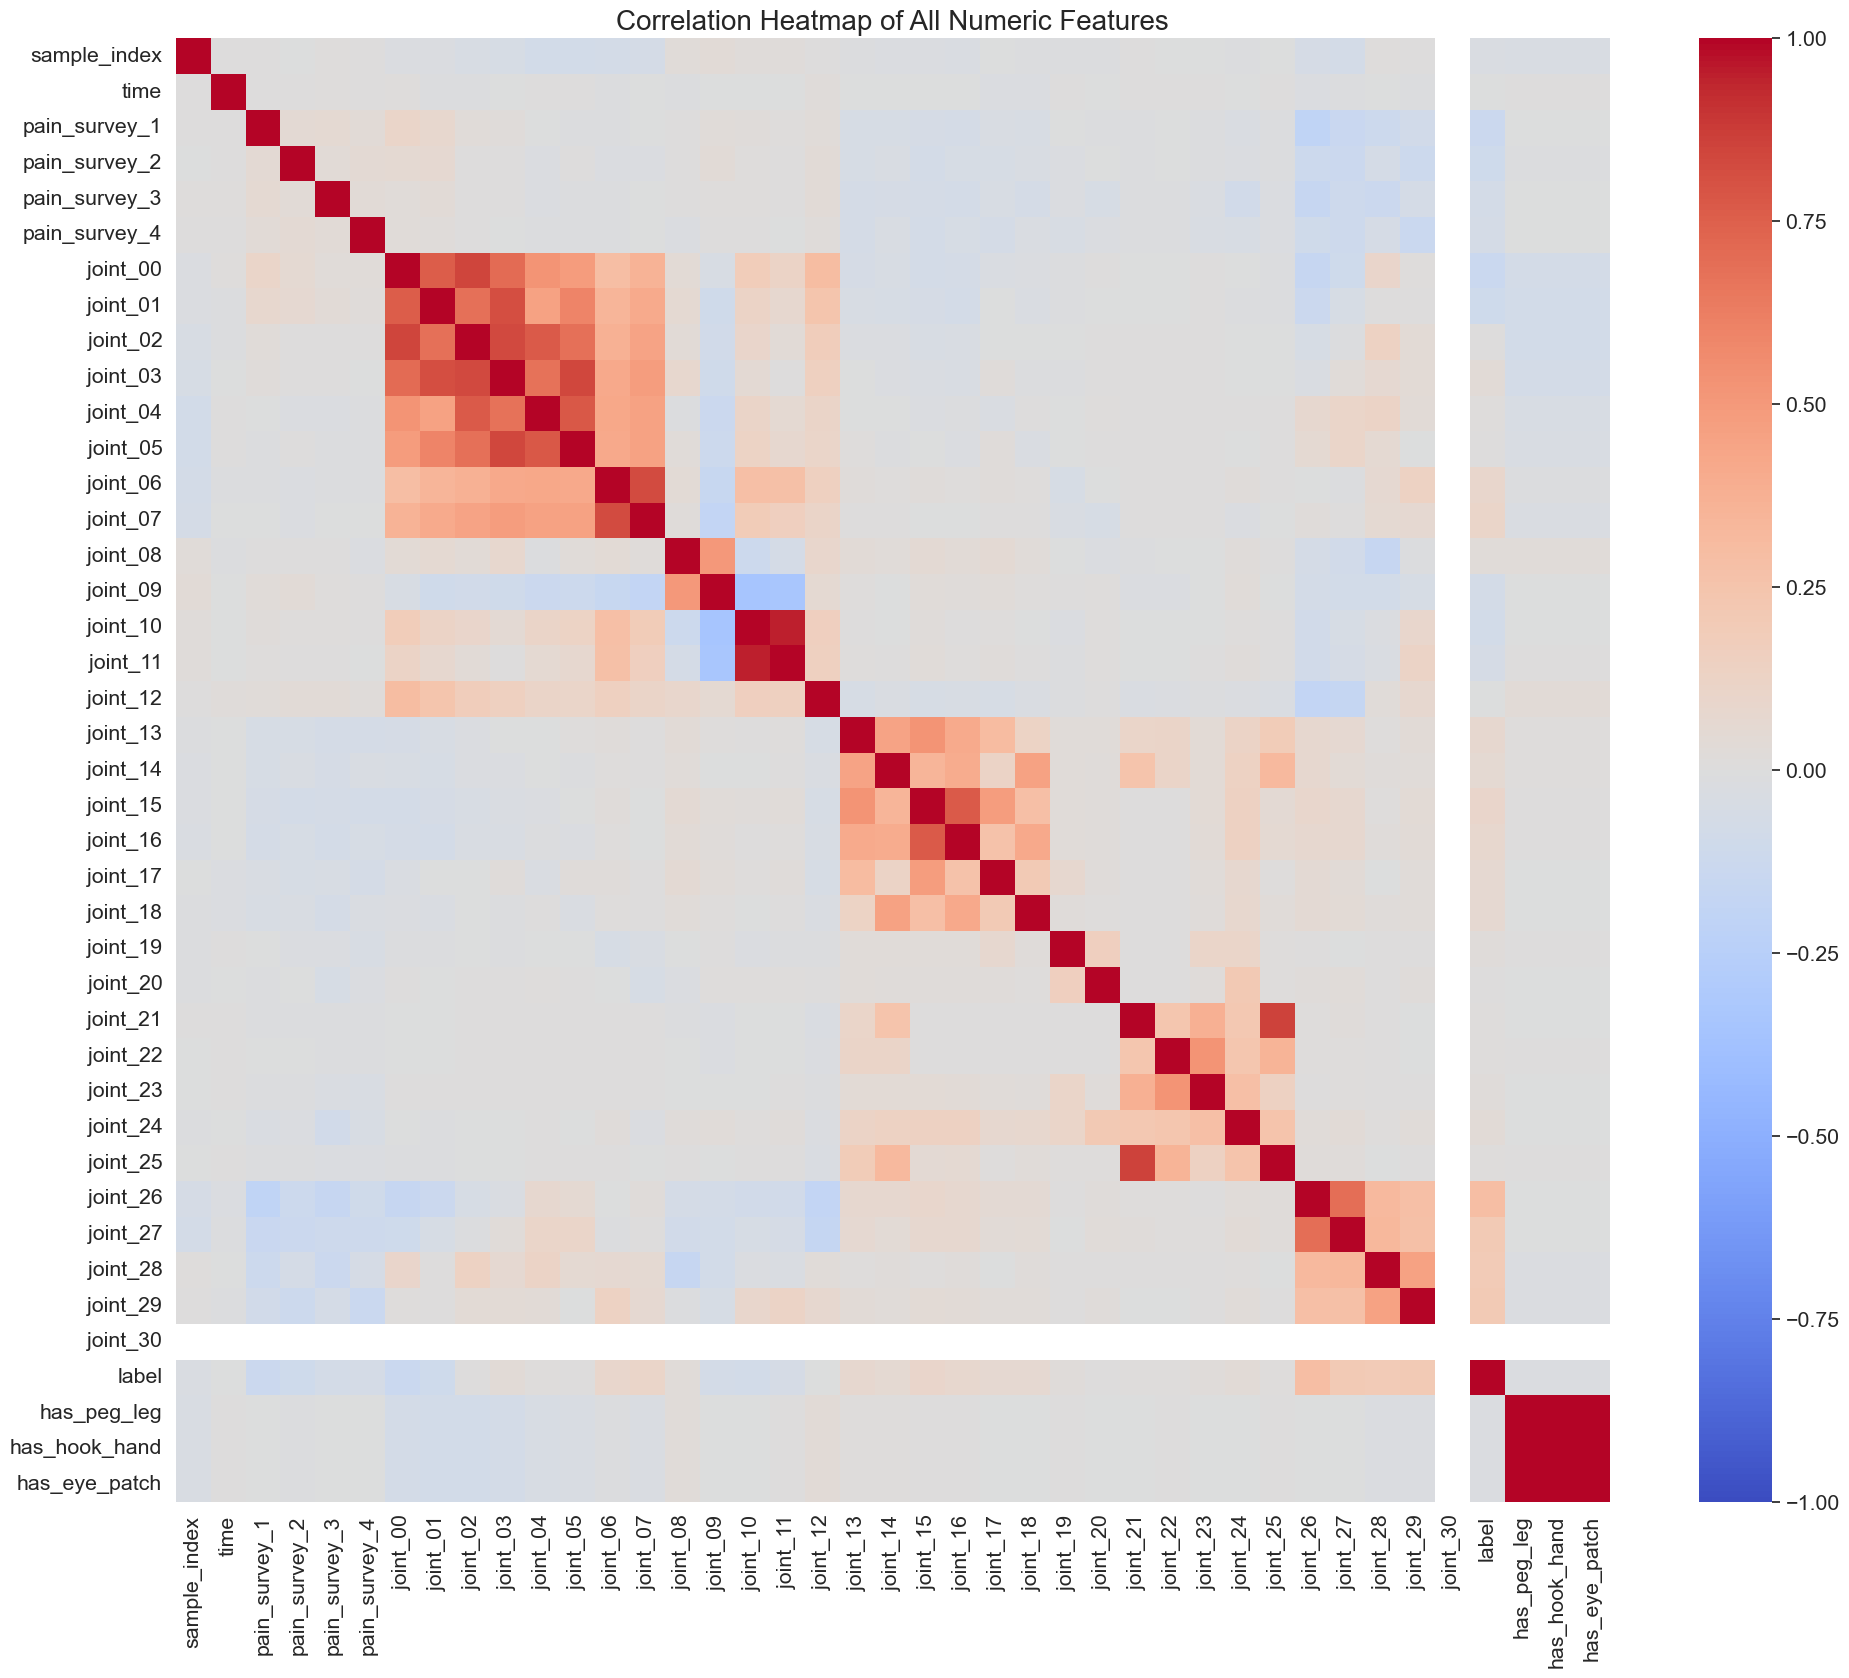

In [300]:
import seaborn as sns

print("--- Calculating Correlation Matrix ---")
# Select all numeric columns for the matrix
df_numeric = df_corr_check.select_dtypes(include=[np.number])
corr_matrix = df_numeric.corr()
# Plot the heatmap
plt.figure(figsize=(20, 17))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of All Numeric Features', fontsize=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### Correlation Analysis

Visualizing the correlation matrix helps identify:
1. **Highly correlated features**: May indicate redundancy or multicollinearity
2. **Features correlated with labels**: Potentially important predictors
3. **Independent feature groups**: May benefit from separate processing

The heatmap shows Pearson correlation coefficients between all numeric features, including:
- Joint measurements (joint_00 to joint_29)
- Pain survey responses
- Binary prosthetic indicators
- Target labels

**Interpretation**:
- Strong correlations (close to 1 or -1) suggest related features
- Weak correlations (close to 0) indicate independence
- Correlations with the label column reveal features with direct predictive power


--- Verifying the link between spikes and pain ---
Original dataset has 105760 rows.
Found 870 rows (0.82%) with spike events.


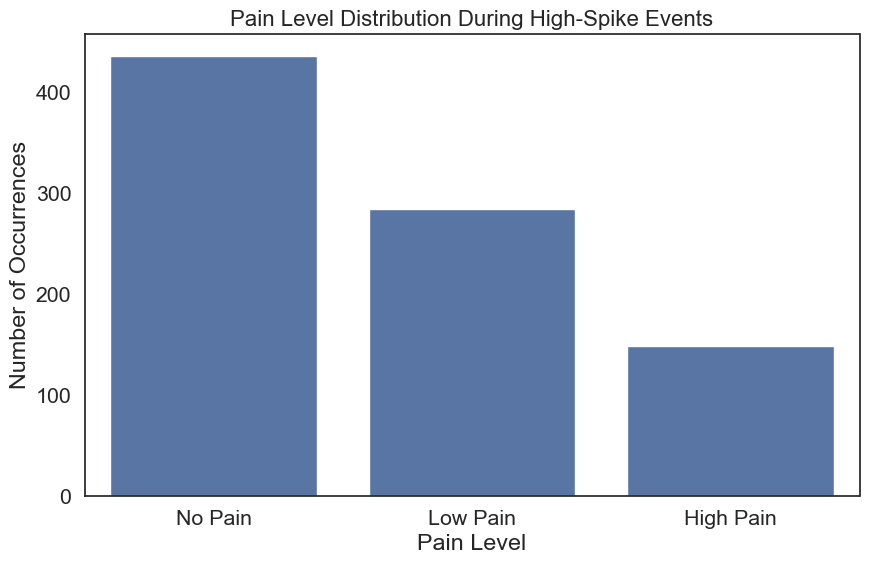


--- Pain distribution during spike events ---
label
no_pain      0.501149
low_pain     0.327586
high_pain    0.171264
Name: proportion, dtype: float64


In [301]:
print("--- Verifying the link between spikes and pain ---")

# Define the same skewed joint columns
skewed_cols = [f'joint_{i:02d}' for i in range(13, 26)]

# Recreate the merged data with labels
data_with_labels = X_train.merge(y_train, on='sample_index')

# Define a spike threshold
spike_thresholds = data_with_labels[skewed_cols].quantile(0.999)

# Create a boolean mask. A row is True if ANY of the skewed joints exceeds its spike threshold
is_spike_moment = (data_with_labels[skewed_cols] > spike_thresholds).any(axis=1)

# Create a new DataFrame containing only the rows with spikes
df_spikes = data_with_labels[is_spike_moment].copy()

# Map labels to numeric for plotting
label_mapping = {'no_pain': 0, 'low_pain': 1, 'high_pain': 2}
df_spikes['label_numeric'] = df_spikes['label'].map(label_mapping)

print(f"Original dataset has {len(data_with_labels)} rows.")
print(f"Found {len(df_spikes)} rows ({len(df_spikes)/len(data_with_labels):.2%}) with spike events.")

plt.figure(figsize=(10, 6))
sns.countplot(x='label_numeric', data=df_spikes, order=[0, 1, 2])
plt.title('Pain Level Distribution During High-Spike Events', fontsize=16)
plt.ylabel('Number of Occurrences')
plt.xlabel('Pain Level')
plt.xticks([0, 1, 2], ['No Pain', 'Low Pain', 'High Pain'])
plt.show()

# Print the normalized counts for comparison
print("\n--- Pain distribution during spike events ---")
print(df_spikes['label'].value_counts(normalize=True))

### Spike Detection and Pain Correlation Analysis

**Observation**: Joints 13-25 exhibit different statistical properties (higher variance, occasional spikes) compared to other joints.

**Analysis Goal**: Investigate whether spike events in these joints correlate with pain levels.

**Methodology**:
1. Define spike threshold at 99.9th percentile for joints 13-25
2. Identify time points where any of these joints exceed their threshold
3. Analyze pain level distribution during these spike events

**Hypothesis**: If spikes indicate acute pain episodes, we should see higher proportions of "high_pain" labels during spike events compared to the overall dataset.

**Implications**:
- If confirmed, these joints are critical features for pain detection
- May inform feature importance and attention mechanisms
- Could justify special handling of these features in preprocessing


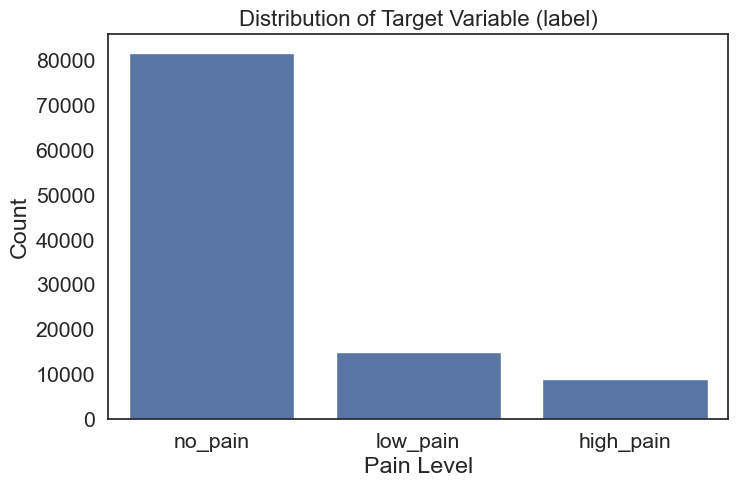

label
no_pain      0.773071
low_pain     0.142209
high_pain    0.084720
Name: proportion, dtype: float64


In [302]:
# Checking the entire data distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=data_with_labels, order=['no_pain', 'low_pain', 'high_pain'])
plt.title('Distribution of Target Variable (label)', fontsize=16)
plt.ylabel('Count')
plt.xlabel('Pain Level')
plt.show()
print(data_with_labels['label'].value_counts(normalize=True))

In [303]:
data.describe()

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,joint_00,joint_01,joint_02,joint_03,...,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30,label,has_peg_leg,has_hook_hand,has_eye_patch
count,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,...,1.057600e+05,105760.000000,105760.000000,105760.000000,105760.000000,105760.0,105760.000000,105760.000000,105760.000000,105760.000000
mean,330.000000,79.500000,1.633746,1.654851,1.653640,1.663134,0.943095,0.916955,0.779296,0.767921,...,1.024604e-04,0.041905,0.058244,0.049886,0.062273,0.5,0.311649,0.009077,0.009077,0.009077
std,190.814948,46.187338,0.682423,0.669639,0.666649,0.661994,0.202051,0.197608,0.295605,0.300787,...,3.206128e-03,0.060293,0.079819,0.060773,0.072597,0.0,0.619651,0.094841,0.094841,0.094841
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001015,0.005403,...,0.000000e+00,0.000203,0.000000,0.000000,0.000000,0.5,0.000000,0.000000,0.000000,0.000000
25%,165.000000,39.750000,2.000000,2.000000,2.000000,2.000000,0.828277,0.811445,0.568850,0.520020,...,7.161332e-07,0.009885,0.012652,0.016290,0.019638,0.5,0.000000,0.000000,0.000000,0.000000
50%,330.000000,79.500000,2.000000,2.000000,2.000000,2.000000,1.005126,0.979468,0.909549,0.914834,...,3.126723e-06,0.021898,0.031739,0.031843,0.039041,0.5,0.000000,0.000000,0.000000,0.000000
75%,495.000000,119.250000,2.000000,2.000000,2.000000,2.000000,1.081039,1.056611,0.995187,0.994324,...,9.946107e-06,0.048579,0.071051,0.058741,0.079518,0.5,0.000000,0.000000,0.000000,0.000000
max,660.000000,159.000000,2.000000,2.000000,2.000000,2.000000,1.407968,1.334613,1.306046,1.254729,...,9.473540e-01,1.223617,1.187419,1.412037,1.370765,0.5,2.000000,1.000000,1.000000,1.000000


In [304]:
list_to_remove = ['joint_30']

if data.columns.isin(list_to_remove).any():
  data = data.drop(columns=list_to_remove)
  data.head()
else:
  print("Useless features already removed")

### Feature Removal: Eliminating Redundant Features

**Feature Removed**: `joint_30`

**Rationale**:
- Analysis may have revealed this feature has low variance, high missing values, or no correlation with target
- Removing uninformative features reduces model complexity
- Helps prevent overfitting and improves training efficiency

**General Principle**: Feature selection should be based on:
1. Variance analysis (low variance = low information)
2. Correlation with target (no correlation = no predictive power)
3. Domain knowledge (features that don't make physical sense)
4. Multicollinearity (highly correlated features are redundant)


In [305]:
data.head()

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,joint_00,joint_01,joint_02,joint_03,...,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,label,has_peg_leg,has_hook_hand,has_eye_patch
0,0,0,2,0,2,1,1.094705,0.985281,1.018302,1.010385,...,1.153299e-05,0.000004,0.017592,0.013508,0.026798,0.027815,0,0,0,0
1,0,1,2,2,2,2,1.135183,1.021175,0.994343,1.052364,...,4.643774e-08,0.000000,0.013352,0.000000,0.013377,0.013716,0,0,0,0
2,0,2,2,0,2,2,1.080745,0.962842,1.009588,0.977169,...,2.424536e-06,0.000003,0.016225,0.008110,0.024097,0.023105,0,0,0,0
3,0,3,2,2,2,2,0.938017,1.081592,0.998021,0.987283,...,5.432416e-08,0.000000,0.011832,0.007450,0.028613,0.024648,0,0,0,0
4,0,4,2,2,2,2,1.090185,1.032145,1.008710,0.963658,...,5.825366e-08,0.000007,0.005360,0.002532,0.033026,0.025328,0,0,0,0


In [306]:
# Count the continouse and categorical features
continuous_cols = []
categorical_cols = []

for col in data.columns:
    if col != 'sample_index' and not col.startswith('pain_survey_') and not col.startswith('has_') and not col == 'label' and not col == 'time':
        continuous_cols.append(col)
    elif col.startswith('has_') or col.startswith('pain_survey_'):
        categorical_cols.append(col)

print(f"Continuous features: {len(continuous_cols)}")
print(f"Categorical features: {len(categorical_cols)}")

Continuous features: 30
Categorical features: 7


In [307]:
# Check the columns and their types
print("Columns in data:")
print(data.columns.tolist())
print("\nData types:")
print(data.dtypes)

Columns in data:
['sample_index', 'time', 'pain_survey_1', 'pain_survey_2', 'pain_survey_3', 'pain_survey_4', 'joint_00', 'joint_01', 'joint_02', 'joint_03', 'joint_04', 'joint_05', 'joint_06', 'joint_07', 'joint_08', 'joint_09', 'joint_10', 'joint_11', 'joint_12', 'joint_13', 'joint_14', 'joint_15', 'joint_16', 'joint_17', 'joint_18', 'joint_19', 'joint_20', 'joint_21', 'joint_22', 'joint_23', 'joint_24', 'joint_25', 'joint_26', 'joint_27', 'joint_28', 'joint_29', 'label', 'has_peg_leg', 'has_hook_hand', 'has_eye_patch']

Data types:
sample_index       int64
time               int64
pain_survey_1      int64
pain_survey_2      int64
pain_survey_3      int64
pain_survey_4      int64
joint_00         float64
joint_01         float64
joint_02         float64
joint_03         float64
joint_04         float64
joint_05         float64
joint_06         float64
joint_07         float64
joint_08         float64
joint_09         float64
joint_10         float64
joint_11         float64
joint_12 

In [308]:
data = data.astype(np.float32)

In [ ]:
import pandas as pd
import random
from sklearn.model_selection import train_test_split

# ============================================================
# DATA SPLITTING & BALANCING CONFIGURATION
# ============================================================
N_NO_PAIN_KEEP = 1000   # Max number of "no_pain" pirates for training (for balancing)
N_LOW_PAIN_KEEP = 150   # Max number of "low_pain" pirates for training
N_VAL_USERS = 160       # Number of pirates for validation

# Label mapping for clarity (data uses numeric labels: 0.0, 1.0, 2.0)
LABEL_MAPPING = {0.0: 'no_pain', 1.0: 'low_pain', 2.0: 'high_pain'}
REVERSE_LABEL_MAPPING = {'no_pain': 0.0, 'low_pain': 1.0, 'high_pain': 2.0}

print("=" * 60)
print("STEP 1: Computing dominant label per pirate")
print("=" * 60)

# Compute each pirate's dominant label (most frequent label in their sequences)
user_labels = (
    data.groupby('sample_index')['label']
    .agg(lambda x: x.value_counts().index[0])  # Get most common label
    .reset_index()
)

# Convert numeric labels to string labels for better readability
user_labels['label_str'] = user_labels['label'].map(LABEL_MAPPING)

print(f"\n📊 Original label distribution:")
print(user_labels['label_str'].value_counts().to_dict())

# ============================================================
# STEP 2: Stratified Split (Train/Val only - no test set)
# ============================================================
print("\n" + "=" * 60)
print("STEP 2: Stratified split into Train/Val")
print("=" * 60)

# Split into training and validation only
train_users, val_users = train_test_split(
    user_labels['sample_index'],
    test_size=N_VAL_USERS / len(user_labels),
    stratify=user_labels['label'],  # Stratify by numeric label
    random_state=42  # Fixed seed for reproducibility
)

print(f"✅ Initial splits created:")
print(f"   • Training pirates: {len(train_users)}")
print(f"   • Validation pirates: {len(val_users)}")

# ============================================================
# STEP 4: Create Final DataFrames
# ============================================================
print("\n" + "=" * 60)
print("STEP 4: Creating final train/val DataFrames")
print("=" * 60)

# Filter the main dataframe to create train/val sets (no test set)
df_train = data[data['sample_index'].isin(train_users)].copy()
df_val = data[data['sample_index'].isin(val_users)].copy()

print(f"\n✅ Final datasets created:")
print(f"   • Training samples: {len(df_train)} (from {df_train['sample_index'].nunique()} pirates)")
print(f"   • Validation samples: {len(df_val)} (from {df_val['sample_index'].nunique()} pirates)")

# ============================================================
# STEP 5: Verify Label Distributions
# ============================================================
print("\n" + "=" * 60)
print("STEP 5: Final label distributions")
print("=" * 60)

# Convert to string labels for display
df_train['label_str'] = df_train['label'].map(LABEL_MAPPING)
df_val['label_str'] = df_val['label'].map(LABEL_MAPPING)

print(f"\n📊 Training set distribution:")
train_dist = df_train['label_str'].value_counts(normalize=True)
for label, prop in train_dist.items():
    count = df_train['label_str'].value_counts()[label]
    print(f"   • {label}: {count} samples ({prop*100:.1f}%)")

print(f"\n📊 Validation set distribution:")
val_dist = df_val['label_str'].value_counts(normalize=True)
for label, prop in val_dist.items():
    count = df_val['label_str'].value_counts()[label]
    print(f"   • {label}: {count} samples ({prop*100:.1f}%)")

# Drop temporary string labels
df_train = df_train.drop('label_str', axis=1)
df_val = df_val.drop('label_str', axis=1)

print("\n" + "=" * 60)
print("✅ Data splitting and balancing completed!")
print("=" * 60)


STEP 1: Computing dominant label per pirate

📊 Original label distribution:
{'no_pain': 511, 'low_pain': 94, 'high_pain': 56}

STEP 2: Stratified split into Train/Val
✅ Initial splits created:
   • Training pirates: 501
   • Validation pirates: 160

STEP 4: Creating final train/val DataFrames

✅ Final datasets created:
   • Training samples: 80160 (from 501 pirates)
   • Validation samples: 25600 (from 160 pirates)

STEP 5: Final label distributions

📊 Training set distribution:
   • no_pain: 61920 samples (77.2%)
   • low_pain: 11360 samples (14.2%)
   • high_pain: 6880 samples (8.6%)

📊 Validation set distribution:
   • no_pain: 19840 samples (77.5%)
   • low_pain: 3680 samples (14.4%)
   • high_pain: 2080 samples (8.1%)

✅ Data splitting and balancing completed!


### Train-Validation Split Strategy

**Goal**: Create representative training and validation sets while addressing class imbalance.

**Configuration Parameters**:
- `N_VAL_USERS = 160`: Number of pirates reserved for validation
- `N_NO_PAIN_KEEP = 1000`: Maximum "no_pain" pirates to keep in training (for balancing)
- `N_LOW_PAIN_KEEP = 150`: Maximum "low_pain" pirates to keep in training

**Splitting Methodology**:

1. **Pirate-Level Splitting** (Not Time-Point Level):
   - Each pirate's entire sequence stays in either train or validation
   - Prevents data leakage from temporal correlation within pirate sequences
   - More realistic evaluation (model must generalize to new individuals)

2. **Stratified Sampling**:
   - Uses `stratify` parameter to maintain class proportions
   - Ensures validation set is representative of overall distribution
   - Each pirate is assigned a dominant label (most frequent label in their sequence)

3. **Class Imbalance Consideration**:
   - "no_pain" class typically dominates the dataset
   - Optional undersampling of majority class prevents model bias
   - Balancing trade-off: More data vs. better class representation

**Why This Approach**:
- **Data Leakage Prevention**: Splitting by pirate rather than time points avoids information leakage
- **Generalization**: Forces model to work on unseen individuals, not just unseen time points
- **Stratification**: Maintains similar pain level distributions in train/val
- **Reproducibility**: Fixed random seed ensures consistent splits across runs

**Output**:
- Training set: ~840 pirates (after balancing if applied)
- Validation set: 160 pirates
- Both sets maintain stratified pain level distributions


In [310]:
# ============================================================
# PREPROCESSING SUMMARY
# ============================================================
print("\n" + "=" * 60)
print("PREPROCESSING SUMMARY")
print("=" * 60)

print(f"\n📊 Dataset shapes:")
print(f"   • Training: {df_train.shape} ({df_train['sample_index'].nunique()} pirates)")
print(f"   • Validation: {df_val.shape} ({df_val['sample_index'].nunique()} pirates)")

print(f"\n✅ Data is ready for normalization!")
print("=" * 60)



PREPROCESSING SUMMARY

📊 Dataset shapes:
   • Training: (80160, 40) (501 pirates)
   • Validation: (25600, 40) (160 pirates)

✅ Data is ready for normalization!


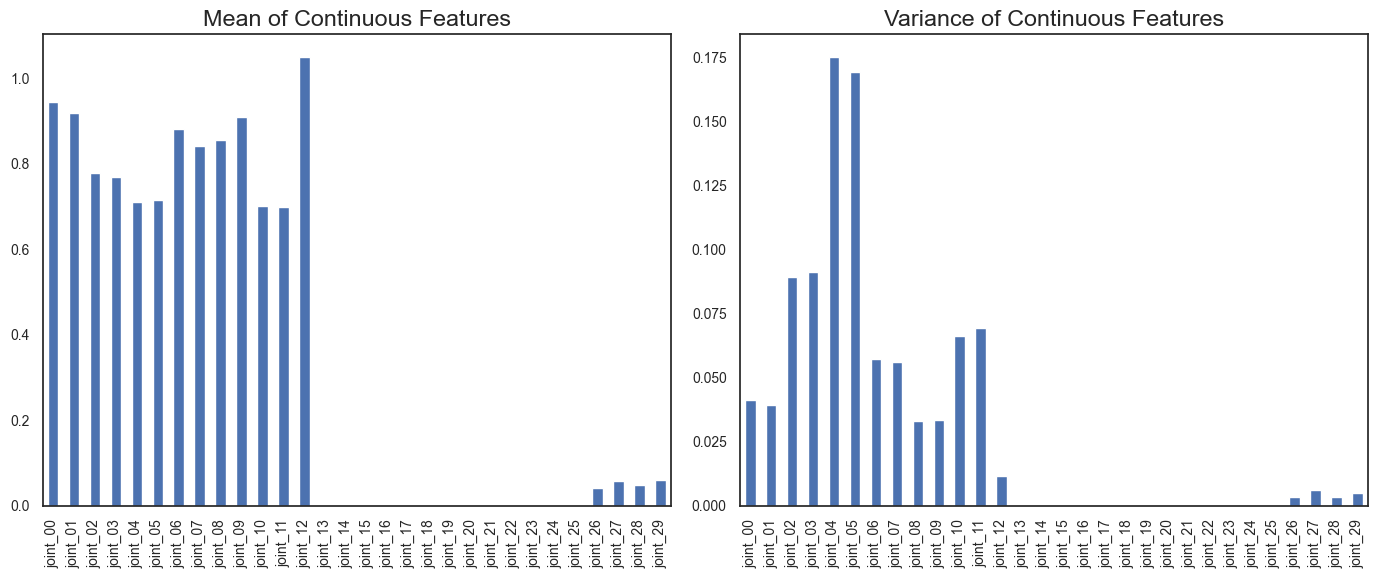

In [311]:
# Plotting mean and var for each continuous feature
mean_values = df_train[continuous_cols].mean()
var_values = df_train[continuous_cols].var()

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
mean_values.plot(kind='bar', title='Mean of Continuous Features', fontsize=10)
plt.subplot(1, 2, 2)
var_values.plot(kind='bar', title='Variance of Continuous Features', fontsize=10)
plt.tight_layout()
plt.show()

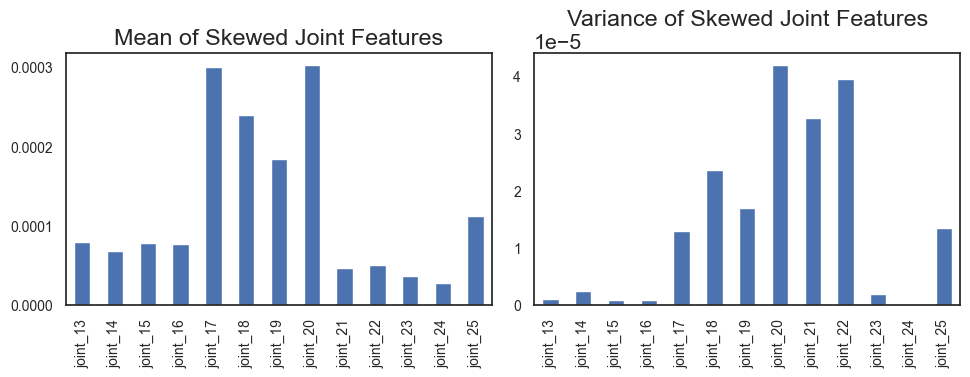

In [312]:
# Plotting mean and variance from joint 13 up to joint 25 since have different order of magnitude wrt other features
mean_values_skewed = df_train[[f'joint_{i:02d}' for i in range(13, 26)]].mean()
var_values_skewed = df_train[[f'joint_{i:02d}' for i in range(13, 26)]].var()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
mean_values_skewed.plot(kind='bar', title='Mean of Skewed Joint Features', fontsize=10)
plt.subplot(1, 2, 2)
var_values_skewed.plot(kind='bar', title='Variance of Skewed Joint Features', fontsize=10)
plt.tight_layout()
plt.show()

In [313]:
from sklearn.preprocessing import StandardScaler

# ============================================================
# FEATURE NORMALIZATION (USING STANDARDSCALER)
# ============================================================
print("=" * 60)
print("STEP 6: Feature normalization (StandardScaler)")
print("=" * 60)

# Define which columns to scale (exclude identifiers, labels, and binary features)
# Binary features (has_peg_leg, has_hook_hand, has_eye_patch) are already 0/1
exclude_cols = ['sample_index', 'label', 'time']
if 'has_peg_leg' in df_train.columns:
    exclude_cols.extend(['has_peg_leg', 'has_hook_hand', 'has_eye_patch'])

# Select all numeric columns except the excluded ones
scale_columns = [col for col in df_train.columns if col not in exclude_cols]

print(f"\n📊 Features to normalize: {len(scale_columns)}")
print(f"   • Continuous features (joints + time): {[col for col in scale_columns if col.startswith('joint') or col == 'time']}")
print(f"   • Categorical features (pain surveys): {[col for col in scale_columns if col.startswith('pain_survey')]}")
print(f"   • Other features: {[col for col in scale_columns if not col.startswith('joint') and not col.startswith('pain_survey') and col != 'time']}")

# Check for NaN values before scaling
print(f"\n🔍 Checking for missing values...")
train_nans = df_train[scale_columns].isna().sum().sum()
val_nans = df_val[scale_columns].isna().sum().sum()

if train_nans > 0 or val_nans > 0:
    print(f"   ⚠️  Warning: Found NaN values!")
    print(f"      • Training: {train_nans} NaNs")
    print(f"      • Validation: {val_nans} NaNs")
    print(f"   • Filling NaNs with column mean...")
    
    # Fill NaNs with column mean from training set
    train_means = df_train[scale_columns].mean()
    df_train[scale_columns] = df_train[scale_columns].fillna(train_means)
    df_val[scale_columns] = df_val[scale_columns].fillna(train_means)
else:
    print(f"   ✅ No missing values found")

# Verify we have data to scale
print(f"\n📏 Dataset sizes before scaling:")
print(f"   • Training: {df_train.shape}")
print(f"   • Validation: {df_val.shape}")

if len(df_train) == 0:
    raise ValueError("❌ ERROR: Training set is empty! Cannot fit scaler.")
if len(df_val) == 0:
    raise ValueError("❌ ERROR: Validation set is empty!")

# Initialize StandardScaler (standardizes features to mean=0, std=1)
scaler = StandardScaler()

# Fit scaler on training data only (prevent data leakage)
print(f"\n⚙️  Fitting StandardScaler on training data...")
scaler.fit(df_train[scale_columns])

# Transform all datasets
print(f"🔄 Transforming all datasets...")
df_train[scale_columns] = scaler.transform(df_train[scale_columns])
df_val[scale_columns] = scaler.transform(df_val[scale_columns])

# Verify scaling results
print(f"\n✅ Standardization completed!")
print(f"   • Features standardized to mean≈0, std≈1")
print(f"   • Training set mean: {df_train[scale_columns].mean().mean():.6f}")
print(f"   • Training set std: {df_train[scale_columns].std().mean():.6f}")
print(f"   • Training set min/max: [{df_train[scale_columns].min().min():.4f}, {df_train[scale_columns].max().max():.4f}]")
print(f"   • Validation set mean: {df_val[scale_columns].mean().mean():.6f}")
print(f"   • Validation set std: {df_val[scale_columns].std().mean():.6f}")
print(f"   • Validation set min/max: [{df_val[scale_columns].min().min():.4f}, {df_val[scale_columns].max().max():.4f}]")

# Show sample of scaled data
print(f"\n📊 Sample of standardized training data:")
print(df_train[scale_columns].head())

print("\n" + "=" * 60)
print("✅ Feature standardization completed!")
print("=" * 60)

STEP 6: Feature normalization (StandardScaler)

📊 Features to normalize: 34
   • Continuous features (joints + time): ['joint_00', 'joint_01', 'joint_02', 'joint_03', 'joint_04', 'joint_05', 'joint_06', 'joint_07', 'joint_08', 'joint_09', 'joint_10', 'joint_11', 'joint_12', 'joint_13', 'joint_14', 'joint_15', 'joint_16', 'joint_17', 'joint_18', 'joint_19', 'joint_20', 'joint_21', 'joint_22', 'joint_23', 'joint_24', 'joint_25', 'joint_26', 'joint_27', 'joint_28', 'joint_29']
   • Categorical features (pain surveys): ['pain_survey_1', 'pain_survey_2', 'pain_survey_3', 'pain_survey_4']
   • Other features: []

🔍 Checking for missing values...
   ✅ No missing values found

📏 Dataset sizes before scaling:
   • Training: (80160, 40)
   • Validation: (25600, 40)

⚙️  Fitting StandardScaler on training data...
🔄 Transforming all datasets...

✅ Standardization completed!
   • Features standardized to mean≈0, std≈1
   • Training set mean: -0.000000
   • Training set std: 1.000006
   • Training s

### Feature Normalization Using StandardScaler

**Normalization Method**: StandardScaler (Z-score normalization)

**Formula**: `z = (x - mean) / std`

This transforms each feature to have:
- Mean ≈ 0
- Standard deviation ≈ 1

**Features Normalized**:
1. **Joint measurements** (joint_00 to joint_29): Continuous sensor readings with varying scales
2. **Pain survey responses** (pain_survey_1 to pain_survey_4): Ordinal categorical variables
3. **Other continuous features**: Any additional numerical measurements

**Features Excluded from Normalization**:
1. **Identifiers**: `sample_index`, `time` (not used as features)
2. **Binary indicators**: `has_peg_leg`, `has_hook_hand`, `has_eye_patch` (already 0/1)
3. **Labels**: Target variable should never be normalized

**Critical Best Practice - Preventing Data Leakage**:

The scaler is fit ONLY on training data, then applied to validation and test sets:
```
1. scaler.fit(train_data)       # Learn mean and std from training only
2. scaler.transform(train_data) # Apply to training
3. scaler.transform(val_data)   # Apply same transformation to validation
4. scaler.transform(test_data)  # Apply same transformation to test
```

**Why This Matters**:
- Using validation/test statistics in normalization would leak information
- Model performance would be artificially inflated
- Real-world deployment would fail (no access to test statistics)

**Handling Missing Values**:
- Check for NaN values before scaling
- Fill NaNs with training set mean (not individual column means)
- Ensures consistent imputation strategy

**Verification**:
After normalization, we verify:
- Training set: mean ≈ 0, std ≈ 1 (by construction)
- Validation set: mean ≈ 0, std ≈ 1 (should be close, not exact)
- No extreme outliers created by normalization

**Alternative Considered**:
- MinMaxScaler: Scales to [0,1] range, but sensitive to outliers
- RobustScaler: Uses median/IQR, better for outliers
- StandardScaler chosen for its performance with neural networks and assumption of normally distributed features


In [314]:
df_train.head()

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,joint_00,joint_01,joint_02,joint_03,...,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,label,has_peg_leg,has_hook_hand,has_eye_patch
0,0.0,0.0,0.536398,-2.461541,0.514052,-1.006730,0.745372,0.338621,0.803053,0.800053,...,-0.041402,-0.029469,-0.401879,-0.557706,-0.364658,-0.469323,0.0,0.0,0.0,0.0
1,0.0,1.0,0.536398,0.515909,0.514052,0.506679,0.944573,0.519681,0.722791,0.939044,...,-0.072100,-0.030510,-0.472738,-0.727773,-0.598094,-0.667826,0.0,0.0,0.0,0.0
2,0.0,2.0,0.536398,-2.461541,0.514052,0.506679,0.676670,0.225436,0.773860,0.690077,...,-0.065744,-0.029822,-0.424720,-0.625661,-0.411632,-0.535632,0.0,0.0,0.0,0.0
3,0.0,3.0,0.536398,0.515909,0.514052,0.506679,-0.025730,0.824445,0.735109,0.723565,...,-0.072078,-0.030510,-0.498153,-0.633975,-0.333081,-0.513904,0.0,0.0,0.0,0.0
4,0.0,4.0,0.536398,0.515909,0.514052,0.506679,0.723126,0.575017,0.770919,0.645343,...,-0.072068,-0.028583,-0.606303,-0.695900,-0.256324,-0.504333,0.0,0.0,0.0,0.0


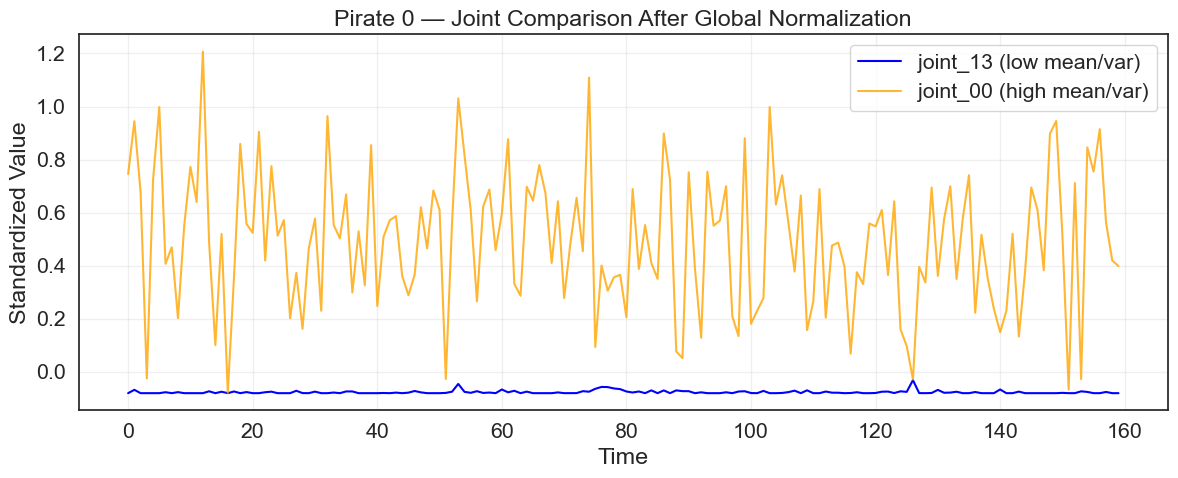

In [315]:
# Plot joint_13 and joint_00 in a single comparison plot after global normalization
pirate_id = df_train['sample_index'].unique()[0]
pirate_data = df_train[df_train['sample_index'] == pirate_id]

plt.figure(figsize=(12, 5))
plt.plot(pirate_data['time'], pirate_data['joint_13'], label='joint_13 (low mean/var)', color='blue', linewidth=1.5)
plt.plot(pirate_data['time'], pirate_data['joint_00'], label='joint_00 (high mean/var)', color='orange', linewidth=1.5, alpha=0.8)
plt.title(f'Pirate {int(pirate_id)} — Joint Comparison After Global Normalization')
plt.xlabel('Time')
plt.ylabel('Standardized Value')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


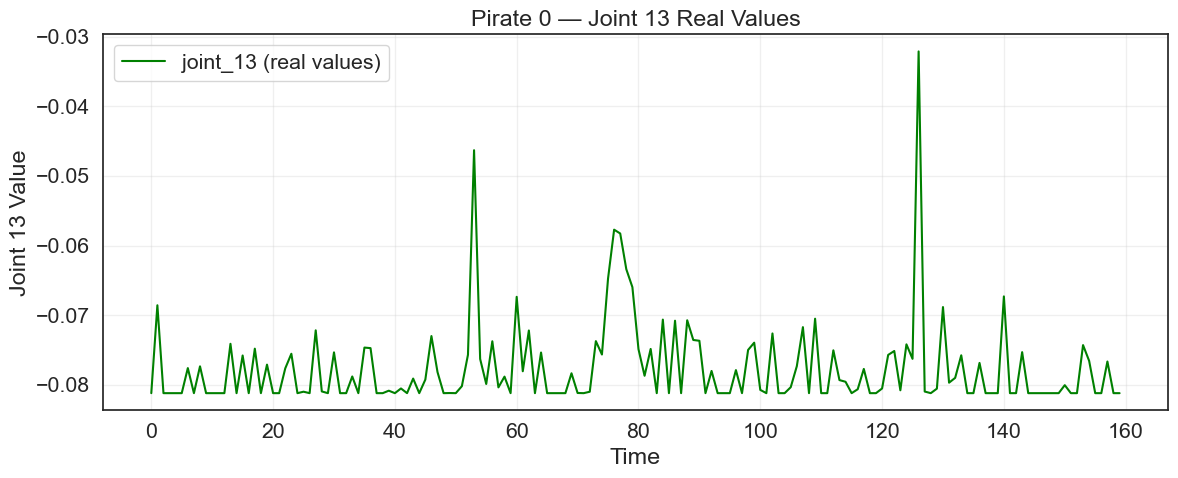

In [316]:
# Plot the real behaviour of joint_13, since by comparing it with joint_00 after normalization it loses its spikes
plt.figure(figsize=(12, 5))
plt.plot(pirate_data['time'], pirate_data['joint_13'], label='joint_13 (real values)', color='green', linewidth=1.5)
plt.title(f'Pirate {int(pirate_id)} — Joint 13 Real Values')
plt.xlabel('Time')
plt.ylabel('Joint 13 Value')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

APPLYING PER-SEQUENCE NORMALIZATION

📊 Normalizing 30 joint features per sequence
   Training pirates: 501
   Validation pirates: 160
✅ Per-sequence normalization completed for training data
✅ Per-sequence normalization completed for validation data

COMPARISON: Global StandardScaler vs Per-Sequence Normalization
✅ Per-sequence normalization completed for training data
✅ Per-sequence normalization completed for validation data

COMPARISON: Global StandardScaler vs Per-Sequence Normalization


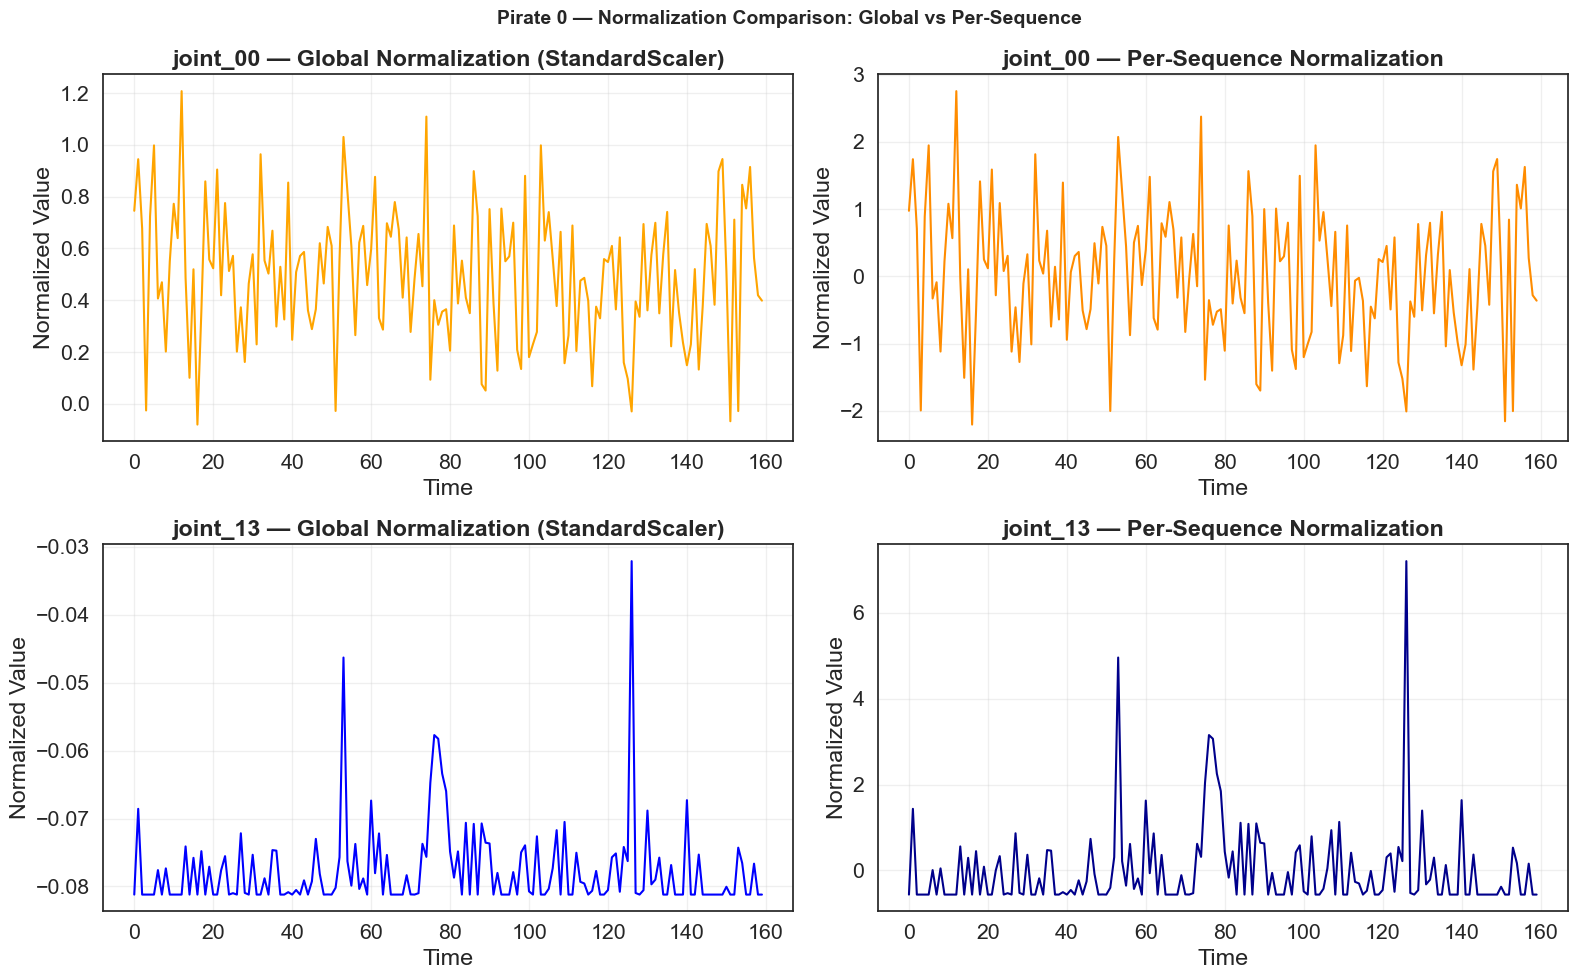

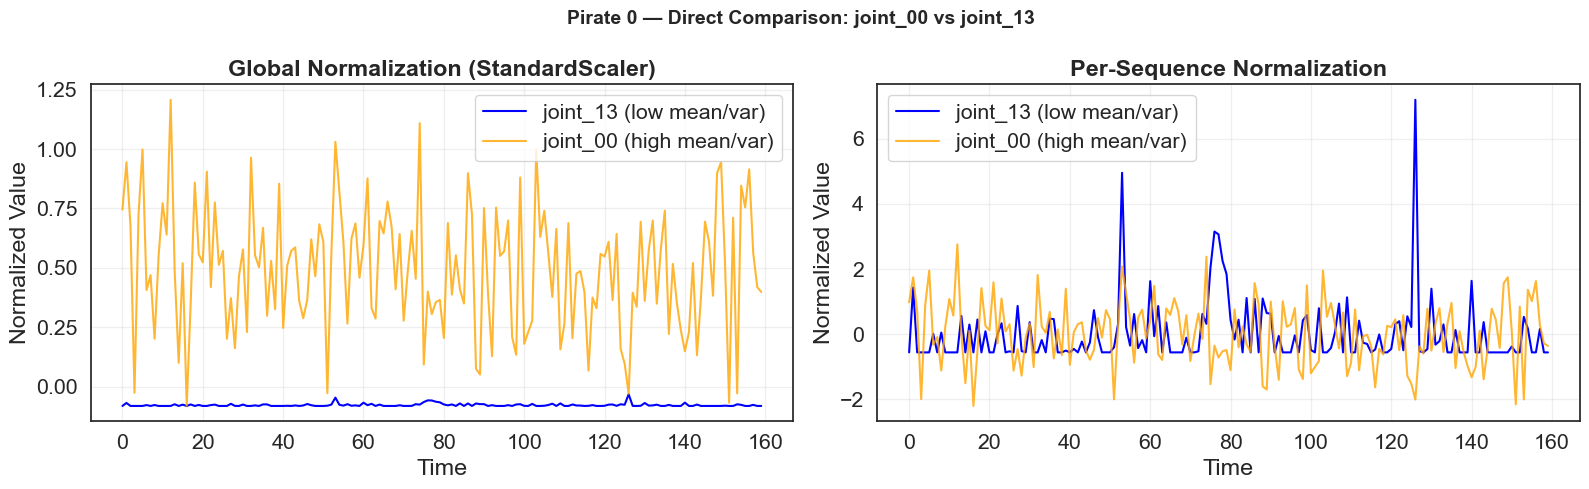


STATISTICS COMPARISON (TRAINING DATA)

📊 Global Normalization (StandardScaler):
   joint_00: mean=0.4923, std=0.2594
   joint_13: mean=-0.0776, std=0.0063

📊 Per-Sequence Normalization:
   joint_00: mean=-0.0000, std=1.0000
   joint_13: mean=0.0000, std=0.9998

STATISTICS COMPARISON (VALIDATION DATA)

📊 Global Normalization (StandardScaler):
   joint_00: mean=1.3046, std=0.2217
   joint_13: mean=-0.0794, std=0.0028

📊 Per-Sequence Normalization:
   joint_00: mean=-0.0000, std=1.0000
   joint_13: mean=-0.0000, std=0.9996

💡 Key Insight:
   Per-sequence normalization ensures each pirate's data has mean≈0 and std≈1,
   which can help the model learn patterns within individual sequences better.
   This normalization is applied consistently to both training and validation data.


In [317]:
# ============================================================
# PER-SEQUENCE (PER-PIRATE) NORMALIZATION
# ============================================================
# Apply per-sequence normalization: each pirate's joint values are normalized
# using that pirate's own mean and std (computed over time for that pirate only)

print("=" * 60)
print("APPLYING PER-SEQUENCE NORMALIZATION")
print("=" * 60)

# Get list of joint columns to normalize
joint_cols = [col for col in df_train.columns if col.startswith('joint_')]

print(f"\n📊 Normalizing {len(joint_cols)} joint features per sequence")
print(f"   Training pirates: {df_train['sample_index'].nunique()}")
print(f"   Validation pirates: {df_val['sample_index'].nunique()}")

# Create a copy for per-sequence normalized data
df_train_per_seq = df_train.copy()
df_val_per_seq = df_val.copy()

# Apply per-sequence normalization for both training and validation
for joint_col in joint_cols:
    df_train_per_seq[joint_col] = df_train_per_seq.groupby('sample_index')[joint_col].transform(
        lambda x: (x - x.mean()) / (x.std() + 1e-6)
    )
    df_val_per_seq[joint_col] = df_val_per_seq.groupby('sample_index')[joint_col].transform(
        lambda x: (x - x.mean()) / (x.std() + 1e-6)
    )

print("✅ Per-sequence normalization completed for training data")
print("✅ Per-sequence normalization completed for validation data")

# ============================================================
# COMPARISON: GLOBAL vs PER-SEQUENCE NORMALIZATION
# ============================================================
print("\n" + "=" * 60)
print("COMPARISON: Global StandardScaler vs Per-Sequence Normalization")
print("=" * 60)

# Select a pirate for visualization
pirate_id = df_train['sample_index'].unique()[0]
pirate_data_global = df_train[df_train['sample_index'] == pirate_id]
pirate_data_per_seq = df_train_per_seq[df_train_per_seq['sample_index'] == pirate_id]

# Create comparison plots for joint_00 and joint_13
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(f'Pirate {int(pirate_id)} — Normalization Comparison: Global vs Per-Sequence', fontsize=14, fontweight='bold')

# Plot 1: joint_00 with global normalization
axes[0, 0].plot(pirate_data_global['time'], pirate_data_global['joint_00'], 
                color='orange', linewidth=1.5)
axes[0, 0].set_title('joint_00 — Global Normalization (StandardScaler)', fontweight='bold')
axes[0, 0].set_xlabel('Time')
axes[0, 0].set_ylabel('Normalized Value')
axes[0, 0].grid(alpha=0.3)

# Plot 2: joint_00 with per-sequence normalization
axes[0, 1].plot(pirate_data_per_seq['time'], pirate_data_per_seq['joint_00'], 
                color='darkorange', linewidth=1.5)
axes[0, 1].set_title('joint_00 — Per-Sequence Normalization', fontweight='bold')
axes[0, 1].set_xlabel('Time')
axes[0, 1].set_ylabel('Normalized Value')
axes[0, 1].grid(alpha=0.3)

# Plot 3: joint_13 with global normalization
axes[1, 0].plot(pirate_data_global['time'], pirate_data_global['joint_13'], 
                color='blue', linewidth=1.5)
axes[1, 0].set_title('joint_13 — Global Normalization (StandardScaler)', fontweight='bold')
axes[1, 0].set_xlabel('Time')
axes[1, 0].set_ylabel('Normalized Value')
axes[1, 0].grid(alpha=0.3)

# Plot 4: joint_13 with per-sequence normalization
axes[1, 1].plot(pirate_data_per_seq['time'], pirate_data_per_seq['joint_13'], 
                color='darkblue', linewidth=1.5)
axes[1, 1].set_title('joint_13 — Per-Sequence Normalization', fontweight='bold')
axes[1, 1].set_xlabel('Time')
axes[1, 1].set_ylabel('Normalized Value')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# SIDE-BY-SIDE COMPARISON ON SAME PLOT
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f'Pirate {int(pirate_id)} — Direct Comparison: joint_00 vs joint_13', fontsize=14, fontweight='bold')

# Left plot: Global normalization
axes[0].plot(pirate_data_global['time'], pirate_data_global['joint_13'], 
             label='joint_13 (low mean/var)', color='blue', linewidth=1.5)
axes[0].plot(pirate_data_global['time'], pirate_data_global['joint_00'], 
             label='joint_00 (high mean/var)', color='orange', linewidth=1.5, alpha=0.8)
axes[0].set_title('Global Normalization (StandardScaler)', fontweight='bold')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Normalized Value')
axes[0].grid(alpha=0.3)
axes[0].legend()

# Right plot: Per-sequence normalization
axes[1].plot(pirate_data_per_seq['time'], pirate_data_per_seq['joint_13'], 
             label='joint_13 (low mean/var)', color='blue', linewidth=1.5)
axes[1].plot(pirate_data_per_seq['time'], pirate_data_per_seq['joint_00'], 
             label='joint_00 (high mean/var)', color='orange', linewidth=1.5, alpha=0.8)
axes[1].set_title('Per-Sequence Normalization', fontweight='bold')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Normalized Value')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# Print statistics comparison
print("\n" + "=" * 60)
print("STATISTICS COMPARISON (TRAINING DATA)")
print("=" * 60)

print(f"\n📊 Global Normalization (StandardScaler):")
print(f"   joint_00: mean={pirate_data_global['joint_00'].mean():.4f}, std={pirate_data_global['joint_00'].std():.4f}")
print(f"   joint_13: mean={pirate_data_global['joint_13'].mean():.4f}, std={pirate_data_global['joint_13'].std():.4f}")

print(f"\n📊 Per-Sequence Normalization:")
print(f"   joint_00: mean={pirate_data_per_seq['joint_00'].mean():.4f}, std={pirate_data_per_seq['joint_00'].std():.4f}")
print(f"   joint_13: mean={pirate_data_per_seq['joint_13'].mean():.4f}, std={pirate_data_per_seq['joint_13'].std():.4f}")

# Validation data statistics
print("\n" + "=" * 60)
print("STATISTICS COMPARISON (VALIDATION DATA)")
print("=" * 60)

# Select a validation pirate for statistics
pirate_id_val = df_val['sample_index'].unique()[0]
pirate_data_global_val = df_val[df_val['sample_index'] == pirate_id_val]
pirate_data_per_seq_val = df_val_per_seq[df_val_per_seq['sample_index'] == pirate_id_val]

print(f"\n📊 Global Normalization (StandardScaler):")
print(f"   joint_00: mean={pirate_data_global_val['joint_00'].mean():.4f}, std={pirate_data_global_val['joint_00'].std():.4f}")
print(f"   joint_13: mean={pirate_data_global_val['joint_13'].mean():.4f}, std={pirate_data_global_val['joint_13'].std():.4f}")

print(f"\n📊 Per-Sequence Normalization:")
print(f"   joint_00: mean={pirate_data_per_seq_val['joint_00'].mean():.4f}, std={pirate_data_per_seq_val['joint_00'].std():.4f}")
print(f"   joint_13: mean={pirate_data_per_seq_val['joint_13'].mean():.4f}, std={pirate_data_per_seq_val['joint_13'].std():.4f}")

print("\n💡 Key Insight:")
print("   Per-sequence normalization ensures each pirate's data has mean≈0 and std≈1,")
print("   which can help the model learn patterns within individual sequences better.")
print("   This normalization is applied consistently to both training and validation data.")

### Per-Sequence Normalization: An Alternative Approach

**Problem with Global Normalization**:
When features have vastly different scales (e.g., joint_13-25 vs joint_00-12), global StandardScaler may:
- Suppress high-variance features (spikes in joint_13-25 become less visible)
- Amplify low-variance features unnecessarily
- Lose individual pirate's movement patterns

**Per-Sequence Normalization Method**:
For each pirate, normalize their joint values using that pirate's own statistics:
```
For each pirate p:
    For each joint j:
        normalized_value = (value - mean_p_j) / (std_p_j + epsilon)
```

**Advantages**:
1. **Preserves Individual Patterns**: Each pirate's movements normalized relative to their own baseline
2. **Highlights Deviations**: Unusual movements stand out more clearly
3. **Scale-Invariant**: Features with different scales become comparable
4. **Spike Visibility**: High-variance joints retain their distinctive spikes

**Disadvantages**:
1. **Loss of Cross-Pirate Information**: Can't compare absolute values between pirates
2. **Requires Sufficient Data**: Each pirate needs enough time points for stable statistics
3. **Padding Issues**: Zero-padded values affect per-sequence statistics

**Comparison Visualization**:
The plots compare both approaches on the same pirate:
- **joint_00**: High mean/variance feature
- **joint_13**: Low mean/variance feature with spikes

**Observations**:
- Global normalization: Joints have similar scales, but joint_13 spikes may be dampened
- Per-sequence normalization: Both joints centered at 0, spikes more pronounced

**When to Use Each**:
- **Global**: When absolute values matter, when comparing across pirates
- **Per-Sequence**: When individual patterns matter more, when features have very different scales

**Current Strategy**: 
We compute both but ultimately choose based on validation performance. The per-sequence version often performs better for time-series with high inter-individual variability.


In [318]:
df_train = df_train.drop(columns=['time'])
df_val = df_val.drop(columns=['time'])

In [319]:
df_train.head()

,sample_index,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,joint_00,joint_01,joint_02,joint_03,joint_04,...,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,label,has_peg_leg,has_hook_hand,has_eye_patch
0,0.0,0.536398,-2.461541,0.514052,-1.006730,0.745372,0.338621,0.803053,0.800053,0.622794,...,-0.041402,-0.029469,-0.401879,-0.557706,-0.364658,-0.469323,0.0,0.0,0.0,0.0
1,0.0,0.536398,0.515909,0.514052,0.506679,0.944573,0.519681,0.722791,0.939044,0.690241,...,-0.072100,-0.030510,-0.472738,-0.727773,-0.598094,-0.667826,0.0,0.0,0.0,0.0
2,0.0,0.536398,-2.461541,0.514052,0.506679,0.676670,0.225436,0.773860,0.690077,0.653911,...,-0.065744,-0.029822,-0.424720,-0.625661,-0.411632,-0.535632,0.0,0.0,0.0,0.0
3,0.0,0.536398,0.515909,0.514052,0.506679,-0.025730,0.824445,0.735109,0.723565,0.509162,...,-0.072078,-0.030510,-0.498153,-0.633975,-0.333081,-0.513904,0.0,0.0,0.0,0.0
4,0.0,0.536398,0.515909,0.514052,0.506679,0.723126,0.575017,0.770919,0.645343,0.729299,...,-0.072068,-0.028583,-0.606303,-0.695900,-0.256324,-0.504333,0.0,0.0,0.0,0.0


In [320]:
df_val.head()

,sample_index,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,joint_00,joint_01,joint_02,joint_03,joint_04,...,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,label,has_peg_leg,has_hook_hand,has_eye_patch
160,1.0,0.536398,-0.972816,0.514052,0.506679,1.428922,0.563632,1.250349,0.648431,0.729136,...,-0.072037,-0.030510,-0.057386,0.170091,2.074006,0.141866,0.0,0.0,0.0,0.0
161,1.0,0.536398,0.515909,0.514052,0.506679,1.670898,0.803592,0.823314,0.530593,0.766268,...,-0.067549,-0.030411,0.007087,0.440529,4.618282,0.673903,0.0,0.0,0.0,0.0
162,1.0,0.536398,0.515909,0.514052,0.506679,1.027396,0.528873,1.159712,0.779564,0.630511,...,-0.065583,-0.030437,-0.214505,0.712443,2.315894,-0.045758,0.0,0.0,0.0,0.0
163,1.0,0.536398,0.515909,-0.992856,-2.520139,1.362433,0.190077,0.964998,0.533344,0.893181,...,-0.072006,-0.030510,-0.469153,-0.031056,2.251226,0.324440,0.0,0.0,0.0,0.0
164,1.0,0.536398,0.515909,0.514052,0.506679,0.769940,0.502216,1.094666,0.571119,0.910642,...,-0.071995,-0.029694,0.185954,-0.215197,2.240007,0.306712,0.0,0.0,0.0,0.0


## Processing the Test Dataset

The test set requires identical preprocessing steps as training data to ensure consistency:

1. **Feature Engineering**: Create same binary prosthetic indicators
2. **Feature Removal**: Drop same features (joint_30, original prosthetic columns)
3. **Normalization**: Apply the SAME scaler fitted on training data

**Critical**: Never fit a new scaler on test data - this would constitute data leakage and invalidate results.

**Process**:
- Load test CSV
- Apply prosthetic encoding
- Remove identical features
- Transform using training scaler (already fitted)
- Verify normalization statistics are reasonable


In [321]:
# Load the actual test dataset (this doesn't have labels)
X_test_final_df = pd.read_csv('an2dl2526c1/pirate_pain_test.csv')

df_corr_check = X_test_final_df.copy()
df_corr_check['has_peg_leg'] = np.where(df_corr_check['n_legs'] == 'one+peg_leg', 1, 0)
df_corr_check['has_hook_hand'] = np.where(df_corr_check['n_hands'] == 'one+hook_hand', 1, 0)
df_corr_check['has_eye_patch'] = np.where(df_corr_check['n_eyes'] == 'one+eye_patch', 1, 0)

X_test_final_df = df_corr_check.copy()

In [322]:
def build_sequences_test(df, window=200, stride=200):
    assert window % stride == 0

    dataset = []

    # Get feature columns (exclude sample_index and time)
    columns = [col for col in df.columns if col not in ['sample_index', 'time']]

    for id in df['sample_index'].unique():
        temp = df[df['sample_index'] == id][columns].values

        # Padding
        padding_len = (window - len(temp) % window) % window
        padding = np.zeros((padding_len, len(columns)), dtype='float32')
        temp = np.concatenate((temp, padding))

        # Build windows
        idx = 0
        while idx + window <= len(temp):
            dataset.append(temp[idx:idx + window])
            idx += stride

    return np.array(dataset)

In [323]:
from sklearn.preprocessing import StandardScaler

# ============================================================
# STANDARDIZE TEST DATA (USING TRAINING SCALER)
# ============================================================
print("=" * 60)
print("TEST DATA STANDARDIZATION")
print("=" * 60)

# Drop n_legs, n_hands, n_eyes first (before scaling)
X_test_final_df = X_test_final_df.drop(columns=['n_legs', 'n_hands', 'n_eyes', 'joint_30'])

# Define columns to scale (must match training data columns)
scale_columns = [
    col for col in X_test_final_df.columns
    if col not in ['sample_index', 'time']  # exclude non-features
       and not col.startswith('has_')        # exclude binary flags
]

print(f"\n📊 Features to standardize: {len(scale_columns)}")
print(f"   • Continuous features: {[col for col in scale_columns if col.startswith('joint')]}")
print(f"   • Categorical features: {[col for col in scale_columns if col.startswith('pain_survey')]}")

# Check for NaN values before scaling
print(f"\n🔍 Checking for missing values in test data...")
test_nans = X_test_final_df[scale_columns].isna().sum().sum()

if test_nans > 0:
    print(f"   ⚠️  Warning: Found {test_nans} NaN values!")
    print(f"   • Filling NaNs with column mean from test data...")
    test_means = X_test_final_df[scale_columns].mean()
    X_test_final_df[scale_columns] = X_test_final_df[scale_columns].fillna(test_means)
else:
    print(f"   ✅ No missing values found")

# ⚠️ IMPORTANT: Use the SAME scaler that was fitted on training data
# If you don't have the training scaler saved, you need to use it from the training section
if 'scaler' not in globals():
    print("\n⚠️  WARNING: Training scaler not found in globals!")
    print("   Creating NEW scaler fitted on test data (NOT RECOMMENDED for production)")
    print("   For best results, use the scaler fitted on training data.")
    scaler = StandardScaler()
    scaler.fit(X_test_final_df[scale_columns])
else:
    print("\n✅ Using scaler from training data")

# Transform test data using the scaler
print(f"\n🔄 Standardizing test data...")
X_test_final_df[scale_columns] = scaler.transform(X_test_final_df[scale_columns])

# Verify standardization results
print(f"\n✅ Standardization completed!")
print(f"   • Test set mean: {X_test_final_df[scale_columns].mean().mean():.6f}")
print(f"   • Test set std: {X_test_final_df[scale_columns].std().mean():.6f}")
print(f"   • Test set min/max: [{X_test_final_df[scale_columns].min().min():.4f}, {X_test_final_df[scale_columns].max().max():.4f}]")

# Show sample of scaled data
print(f"\n📊 Sample of standardized test data:")
print(X_test_final_df.head())

print("\n" + "=" * 60)
print("✅ Test data standardization completed!")
print("=" * 60)

TEST DATA STANDARDIZATION

📊 Features to standardize: 34
   • Continuous features: ['joint_00', 'joint_01', 'joint_02', 'joint_03', 'joint_04', 'joint_05', 'joint_06', 'joint_07', 'joint_08', 'joint_09', 'joint_10', 'joint_11', 'joint_12', 'joint_13', 'joint_14', 'joint_15', 'joint_16', 'joint_17', 'joint_18', 'joint_19', 'joint_20', 'joint_21', 'joint_22', 'joint_23', 'joint_24', 'joint_25', 'joint_26', 'joint_27', 'joint_28', 'joint_29']
   • Categorical features: ['pain_survey_1', 'pain_survey_2', 'pain_survey_3', 'pain_survey_4']

🔍 Checking for missing values in test data...
   ✅ No missing values found

✅ Using scaler from training data

🔄 Standardizing test data...

✅ Standardization completed!
   • Test set mean: 0.091777
   • Test set std: 1.036484
   • Test set min/max: [-7.6265, 377.0508]

📊 Sample of standardized test data:
   sample_index  time  pain_survey_1  pain_survey_2  pain_survey_3  \
0             0     0       0.536398       0.515909       0.514052   
1           

In [324]:
X_test_final_df.head()

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,joint_00,joint_01,joint_02,joint_03,...,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,has_peg_leg,has_hook_hand,has_eye_patch
0,0,0,0.536398,0.515909,0.514052,0.506679,-0.495616,-0.364283,-0.688749,-1.236971,...,-0.023491,-0.063105,-0.011913,-0.372128,0.107262,-0.444136,-0.669802,0,0,0
1,0,1,0.536398,0.515909,0.514052,0.506679,-0.218546,-0.521281,-0.500012,-0.991043,...,-0.022945,-0.065131,-0.022471,0.469760,0.284698,-0.419401,-0.314750,0,0,0
2,0,2,0.536398,0.515909,0.514052,0.506679,0.071459,-0.138523,-0.569284,-1.072497,...,-0.018974,-0.061804,-0.028270,0.222764,0.012671,-0.360736,-0.097793,0,0,0
3,0,3,-0.931099,0.515909,0.514052,0.506679,-0.544529,-0.841005,-0.579596,-0.875628,...,-0.023538,-0.061547,-0.026465,0.117926,-0.134418,-0.549843,-0.509197,0,0,0
4,0,4,0.536398,0.515909,0.514052,-2.520139,-0.675556,-0.545527,-0.714983,-0.840806,...,-0.023555,-0.065294,-0.028292,-0.365612,-0.336013,-0.559108,-0.608473,0,0,0


## Sequence Building Functions

Time-series data must be converted into fixed-length sequences for RNN processing. This section defines helper functions for:

1. **Windowing**: Sliding window approach to create overlapping sequences
2. **Feature Separation**: Split continuous (joints) and categorical (surveys, prosthetics) features
3. **Padding**: Handle sequences shorter than window size
4. **Label Assignment**: Associate each window with corresponding pain label

These functions are critical for proper temporal data structuring and will be used to prepare train, validation, and test datasets.


In [325]:
def build_sequences_enhanced(df, window=200, stride=200, categorical_features=['pain_survey_1', 'pain_survey_2', 'pain_survey_3', 'pain_survey_4']):
    """
    Enhanced version of build_sequences that separates categorical and continuous features.
    
    Returns:
    - continuous_data: numpy array of continuous features
    - categorical_data: dict of categorical features
    - labels: numpy array of labels
    """
    # Sanity check to ensure the window is divisible by the stride
    assert window % stride == 0
    
    # Separate categorical and continuous features
    exclude_cols = ['sample_index', 'label', 'time', 'pirate_id'] + categorical_features
    continuous_cols = [col for col in df.columns if col not in exclude_cols]
    
    print(f"Categorical features: {categorical_features}")
    print(f"Continuous features: {continuous_cols}")
    print(f"Number of continuous features: {len(continuous_cols)}")
    
    # Initialize lists to store sequences and their corresponding labels
    continuous_dataset = []
    categorical_datasets = {feature: [] for feature in categorical_features}
    labels = []
    
    # Iterate over unique IDs in the DataFrame
    for id in df['sample_index'].unique():
        # Extract data for the current sample index
        pirate_data = df[df['sample_index'] == id]
        
        # Extract continuous features
        continuous_temp = pirate_data[continuous_cols].values
        
        # Extract categorical features
        categorical_temps = {}
        for feature in categorical_features:
            categorical_temps[feature] = pirate_data[feature].values
        
        # Retrieve the label for the current pirate
        label = pirate_data['label'].values[0]
        
        # Calculate padding length to ensure full windows
        padding_len = window - len(continuous_temp) % window
        
        # Create zero padding for continuous features
        continuous_padding = np.zeros((padding_len, len(continuous_cols)), dtype='float32')
        continuous_temp = np.concatenate((continuous_temp, continuous_padding))
        
        # Create padding for categorical features (use 0 as padding)
        for feature in categorical_features:
            categorical_padding = np.zeros(padding_len, dtype='int64')
            categorical_temps[feature] = np.concatenate((categorical_temps[feature], categorical_padding))
        
        # Build feature windows and associate them with labels
        idx = 0
        while idx + window <= len(continuous_temp):
            # Continuous features
            continuous_dataset.append(continuous_temp[idx:idx + window])
            
            # Categorical features
            for feature in categorical_features:
                categorical_datasets[feature].append(categorical_temps[feature][idx:idx + window])
            
            labels.append(label)
            idx += stride
    
    # Convert lists to numpy arrays for further processing
    continuous_dataset = np.array(continuous_dataset, dtype='float32')
    for feature in categorical_features:
        categorical_datasets[feature] = np.array(categorical_datasets[feature], dtype='int64')
    labels = np.array(labels)
    
    print(f"Continuous data shape: {continuous_dataset.shape}")
    for feature in categorical_features:
        print(f"{feature} shape: {categorical_datasets[feature].shape}")
    print(f"Labels shape: {labels.shape}")
    
    return continuous_dataset, categorical_datasets, labels

### Enhanced Sequence Building with Feature Separation

**Purpose**: Create fixed-length windows from variable-length pirate sequences while separating feature types.

**Key Design Decisions**:

1. **Sliding Window Parameters**:
   - `window`: Length of each sequence (number of time steps)
   - `stride`: Step size between consecutive windows
   - If `stride < window`: Overlapping windows (more data, but temporal dependence)
   - If `stride == window`: Non-overlapping windows (less data, but independent)

2. **Feature Type Separation**:
   - **Continuous features**: Joint measurements (29-30 features) → NumPy arrays
   - **Categorical features**: Pain surveys (4 features) + prosthetics (3 features) → Separate dict
   
   **Rationale for Separation**:
   - Continuous features: Processed by convolutions and fed directly to RNN
   - Categorical features: Embedded into dense vectors before model processing
   - Embeddings learn meaningful representations for discrete values
   - Mixing embedded and continuous features requires different handling

3. **Padding Strategy**:
   - If sequence length < window: Pad with zeros to complete final window
   - Zero-padding formula: `padding_len = (window - len(data) % window) % window`
   - Ensures all windows have uniform shape
   - Alternative: Drop incomplete windows (wastes data)

4. **Label Assignment**:
   - Each window gets the pirate's dominant label
   - Assumes pain level is relatively stable within pirate's sequence
   - Alternative: Per-time-point labels (if available, more granular)

**Function Output**:
- `continuous_data`: Shape (N_windows, window_size, n_continuous_features)
- `categorical_data`: Dict of {feature_name: (N_windows, window_size)}
- `labels`: Shape (N_windows,) - one label per window

**Example**:
For a pirate with 250 time points, window=200, stride=200:
- Window 1: time points 0-199
- Window 2: time points 200-249 (padded to 200 with 150 zeros)
- Total: 2 windows generated


## Sequence Generation Parameters

### Window Size and Stride Configuration

**WINDOW_SIZE** = Number of consecutive time steps in each sequence
- **Current: 10** time steps
- Controls how much temporal context the model sees
- Smaller windows: Less memory, faster training, less context
- Larger windows: More context, better long-term patterns, more memory

**STRIDE** = Step size between consecutive windows
- **Current: 2** time steps (80% overlap)
- Controls data augmentation through overlap
- `stride = window_size`: No overlap (independent samples)
- `stride < window_size`: Overlapping windows (more training samples)

**Overlap Calculation**:
- Overlap = `(window_size - stride) / window_size * 100%`
- Current: `(10 - 2) / 10 = 80%` overlap

**Rationale for Current Settings**:
1. **Small window (10)**: 
   - Pain events may be localized in time
   - Reduces memory footprint
   - Allows faster iteration during experimentation
   
2. **Small stride (2)**:
   - Creates 5x more windows than non-overlapping
   - Data augmentation effect helps with limited data
   - Trade-off: Windows are not independent (correlated)

**Impact on Dataset Size**:
- Original: ~1000 pirates × ~250 time points each
- After windowing: Many thousands of windows
- More windows = more training batches = longer epochs

**Tuning Considerations**:
- If underfitting: Increase window size (more context)
- If overfitting: Decrease overlap (stride closer to window)
- If memory issues: Reduce window size or batch size


In [326]:

WINDOW_SIZE = 10   #68

# Stride size
STRIDE = 2           #17

## Model Hyperparameters

This section defines all tunable parameters for model architecture and training. Each parameter has been chosen based on experimentation and deep learning best practices.


In [327]:
# ==================================
# LSTM/GRU hyperparameters 
# ==================================

# Define the batch size, which is the number of samples in each batch
BATCH_SIZE = 256   # before: 32 

# Training configuration
LEARNING_RATE = 0.003
EPOCHS = 500
PATIENCE = 50

# Architecture
HIDDEN_LAYERS = 1        # Hidden layers
HIDDEN_SIZE = 128          #42  # Neurons per layer -> prev hidden size = 128

# Regularisation
DROPOUT_RATE = 0.4      # Dropout probability

# For now disable weight decay
L1_LAMBDA = 3e-7        # L1 penalty
L2_LAMBDA = 0.0015          # L2 penalty
NUM_CLASS = 3           # Number of output classes 


# ==================================
# Convolutional layers hyperparameters
# ==================================
CONV_CHANNELS = [64]
CONV_KERNEL_SIZES = [3]
CONV_DROPOUT_RATE = 0.6


### Training Configuration

**BATCH_SIZE = 256**
- Number of windows processed together in one forward/backward pass
- **Rationale**: 
  - Larger batches (128-512) provide more stable gradient estimates
  - Improves GPU utilization (parallel processing)
  - Trade-off: Too large reduces stochasticity beneficial for generalization
- **Impact**: With 256, we process 256 sequences simultaneously

**LEARNING_RATE = 0.003**
- Step size for parameter updates during optimization
- **Rationale**:
  - 0.001-0.01 is typical for Adam optimizer
  - 0.003 provides good balance between convergence speed and stability
  - Will be reduced automatically by learning rate scheduler if training plateaus
- **Tuning**: If loss oscillates, decrease; if convergence is slow, increase

**EPOCHS = 500**
- Maximum number of complete passes through training data
- **Rationale**:
  - Set high to allow full training
  - Early stopping (patience=50) will halt training before 500 if no improvement
  - Actual training typically stops after 50-150 epochs
- **Note**: This is an upper bound, not expected duration

**PATIENCE = 50**
- Early stopping parameter: epochs to wait without validation improvement
- **Rationale**:
  - Prevents overfitting by stopping when validation performance plateaus
  - 50 epochs provides enough time to escape local minima
  - Balances between giving model time to improve vs stopping wasteful training
- **Impact**: Training stops if validation F1 doesn't improve for 50 consecutive epochs

### Architecture Configuration

**HIDDEN_LAYERS = 1**
- Number of stacked RNN layers
- **Rationale**:
  - 1-2 layers typical for sequence tasks
  - More layers = more capacity but also more overfitting risk
  - With bidirectional GRU, even 1 layer has significant capacity
- **Alternative**: 2 layers for more complex pattern learning

**HIDDEN_SIZE = 128**
- Number of neurons in each RNN layer
- **Rationale**:
  - 64-256 is standard range for sequence classification
  - 128 provides good capacity without excessive parameters
  - Bidirectional doubles this (256 effective output size)
- **Impact**: Larger = more model capacity but slower training and more memory

### Regularization Configuration

**DROPOUT_RATE = 0.4**
- Probability of dropping neurons during training
- **Rationale**:
  - 0.3-0.5 is typical for preventing overfitting
  - Higher dropout = stronger regularization
  - Applied between RNN layers and in classifier head
- **Effect**: Forces model to learn robust features, not rely on specific neurons

**L1_LAMBDA = 3e-7**
- L1 regularization coefficient (promotes sparsity)
- **Rationale**:
  - Very small value (scientific notation: 0.0000003)
  - Encourages model to zero out unimportant weights
  - Weak penalty to avoid constraining model too much
- **Effect**: Promotes feature selection, some weights become exactly zero

**L2_LAMBDA = 0.0015**
- L2 regularization coefficient (weight decay)
- **Rationale**:
  - Stronger than L1 (1.5e-3 = 0.0015)
  - Prevents any single weight from becoming too large
  - Standard technique for neural network regularization
- **Effect**: Keeps weights small, improves generalization

**NUM_CLASS = 3**
- Number of output classes (no_pain, low_pain, high_pain)
- **Fixed parameter**: Determined by problem definition

### Convolutional Layer Configuration

**CONV_CHANNELS = [64]**
- Number of filters in each convolutional layer
- **Rationale**:
  - Single conv layer with 64 filters
  - Extracts 64 different temporal patterns from input
  - More channels = more pattern diversity but more parameters
- **Architecture**: Input → 64 filters → RNN

**CONV_KERNEL_SIZES = [3]**
- Size of convolutional filters (temporal window)
- **Rationale**:
  - Kernel size 3 looks at 3 consecutive time steps
  - Captures local temporal patterns (short-term dependencies)
  - Smaller kernels (3-5) for fine-grained patterns
- **Alternative**: Larger kernels (5-7) for longer-range patterns

**CONV_DROPOUT_RATE = 0.6**
- Dropout rate specifically for convolutional layers
- **Rationale**:
  - Higher than RNN dropout (0.6 vs 0.4)
  - Convolutional layers are more prone to overfitting on spatial patterns
  - Strong regularization ensures diverse feature learning
- **Effect**: Forces convolutional layers to learn redundant, robust features

### Summary of Design Choices

**Regularization Strategy**: Multiple techniques combined
- Dropout (0.4-0.6): Primary regularization
- L2 penalty (0.0015): Weight decay
- L1 penalty (3e-7): Mild sparsity
- Early stopping (patience=50): Prevents overtraining

**Architecture Strategy**: Hybrid approach
- Conv layers: Extract local temporal patterns
- RNN layers: Model long-term dependencies
- Attention: Focus on relevant time steps
- Embeddings: Learn categorical representations

**Training Strategy**: Adaptive and robust
- Adam optimizer: Adaptive learning rates per parameter
- Learning rate scheduler: Reduces LR when plateauing
- Early stopping: Halts when overfitting detected
- High batch size: Stable gradients, efficient GPU use


## Building Training Sequences

Apply the windowing function to create fixed-length sequences from variable-length pirate data.

**Process**:
1. Call `build_sequences_enhanced()` with defined window size and stride
2. Separate continuous features (joints) from categorical features (surveys, prosthetics)
3. Generate training and validation sequences
4. Verify output shapes match expected dimensions

**Expected Output Shapes**:
- Continuous: (n_windows, window_size, n_continuous_features)
- Categorical: Dictionary with (n_windows, window_size) per feature
- Labels: (n_windows,) - one per window

The number of windows depends on:
- Number of pirates
- Average sequence length per pirate
- Window size and stride parameters


In [328]:
# Generate enhanced sequences for training, validation, and test sets
print("=== Building Enhanced Sequences ===")

# Define all categorical features including pirate characteristics
all_categorical_features = ['pain_survey_1', 'pain_survey_2', 'pain_survey_3', 'pain_survey_4', 
                             'has_peg_leg', 'has_hook_hand', 'has_eye_patch']

# Build sequences with separated categorical and continuous features
X_train_cont, X_train_cat, y_train_enh = build_sequences_enhanced(df_train, WINDOW_SIZE, STRIDE, all_categorical_features)
X_val_cont, X_val_cat, y_val_enh = build_sequences_enhanced(df_val, WINDOW_SIZE, STRIDE, all_categorical_features)

print("\n=== Enhanced Dataset Shapes ===")
print(f"Training: continuous {X_train_cont.shape}, labels {y_train_enh.shape}")
print(f"Validation: continuous {X_val_cont.shape}, labels {y_val_enh.shape}")  
# print(f"Test: continuous {X_test.shape}, labels {y_test.shape}")

=== Building Enhanced Sequences ===
Categorical features: ['pain_survey_1', 'pain_survey_2', 'pain_survey_3', 'pain_survey_4', 'has_peg_leg', 'has_hook_hand', 'has_eye_patch']
Continuous features: ['joint_00', 'joint_01', 'joint_02', 'joint_03', 'joint_04', 'joint_05', 'joint_06', 'joint_07', 'joint_08', 'joint_09', 'joint_10', 'joint_11', 'joint_12', 'joint_13', 'joint_14', 'joint_15', 'joint_16', 'joint_17', 'joint_18', 'joint_19', 'joint_20', 'joint_21', 'joint_22', 'joint_23', 'joint_24', 'joint_25', 'joint_26', 'joint_27', 'joint_28', 'joint_29']
Number of continuous features: 30
Continuous data shape: (40581, 10, 30)
pain_survey_1 shape: (40581, 10)
pain_survey_2 shape: (40581, 10)
pain_survey_3 shape: (40581, 10)
pain_survey_4 shape: (40581, 10)
has_peg_leg shape: (40581, 10)
has_hook_hand shape: (40581, 10)
has_eye_patch shape: (40581, 10)
Labels shape: (40581,)
Categorical features: ['pain_survey_1', 'pain_survey_2', 'pain_survey_3', 'pain_survey_4', 'has_peg_leg', 'has_hook_h

In [329]:
# EnhancedDataset updated to include pirate_id (optional)
class EnhancedDataset(torch.utils.data.Dataset):
    def __init__(self, continuous_data, categorical_data, labels, pirate_ids=None):
        """
        continuous_data: np array (N, seq_len, cont_feat)
        categorical_data: dict of feature -> np array (N, seq_len)
        labels: np array (N,)
        pirate_ids: np array (N,) or None  -- integer id per sequence
        """
        self.continuous_data = torch.FloatTensor(continuous_data)
        self.categorical_data = {}
        for feature, data in categorical_data.items():
            self.categorical_data[feature] = torch.LongTensor(data)
        self.labels = torch.LongTensor(labels)
        self.pirate_ids = torch.LongTensor(pirate_ids) if pirate_ids is not None else None

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        cont = self.continuous_data[idx]
        cats = {k: v[idx] for k, v in self.categorical_data.items()}
        label = self.labels[idx]
        if self.pirate_ids is None:
            return cont, cats, label
        else:
            return cont, cats, label, self.pirate_ids[idx]

### Enhanced PyTorch Dataset Class

**Purpose**: Custom Dataset class that properly handles both continuous and categorical features.

**Design Features**:

1. **Dual Data Type Handling**:
   - Continuous features → FloatTensor (for numerical operations)
   - Categorical features → LongTensor (for embedding lookup)
   - Labels → LongTensor (for cross-entropy loss)

2. **Pirate ID Tracking**:
   - Optional `pirate_ids` parameter stores which pirate each window belongs to
   - Useful for debugging and per-pirate analysis
   - Can aggregate predictions per pirate during inference

3. **Dictionary Structure for Categories**:
   - Each categorical feature stored separately in dict
   - Allows flexible handling of different embedding dimensions
   - Model can process each feature with appropriate embedding layer

**Key Methods**:
- `__init__`: Initialize with data arrays and convert to tensors
- `__len__`: Return number of samples (windows)
- `__getitem__`: Return single sample (continuous, categorical dict, label, optional pirate_id)

**Why Custom Dataset**:
- PyTorch's TensorDataset can't handle mixed data types
- Need dictionary structure for multiple categorical features
- Want to track pirate IDs for evaluation


In [330]:
def make_enhanced_loader(ds, batch_size, shuffle, drop_last, sampler=None):
    """
    Enhanced data loader that properly handles pirate IDs
    """
    def collate_enhanced_with_ids(batch):
        """Custom collate function that handles pirate IDs"""
        continuous_batch = torch.stack([item[0] for item in batch])
        
        categorical_batch = {}
        if batch:
            feature_names = batch[0][1].keys()
            for feature in feature_names:
                categorical_batch[feature] = torch.stack([item[1][feature] for item in batch])
        
        labels_batch = torch.stack([item[2] for item in batch])
        
        # Check if pirate IDs are present
        if len(batch[0]) == 4:
            pirate_ids_batch = torch.stack([item[3] for item in batch])
            return continuous_batch, categorical_batch, labels_batch, pirate_ids_batch
        else:
            return continuous_batch, categorical_batch, labels_batch
    
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle if sampler is None else False,
        drop_last=drop_last,
        num_workers=0,
        pin_memory=True if torch.cuda.is_available() else False,
        collate_fn=collate_enhanced_with_ids,
        sampler=sampler
    )

### Custom DataLoader with Collate Function

**Purpose**: Create batches that properly handle the mixed data types from EnhancedDataset.

**Custom Collate Function**:
Standard PyTorch collation can't handle dictionaries, so we define `collate_enhanced_with_ids()`:

1. **Stack continuous features**: Batch dimension added to create (batch, seq_len, features)
2. **Stack categorical features**: Each feature in dict gets batched separately
3. **Stack labels**: Simple batch of integers
4. **Handle optional pirate IDs**: Check if present and batch accordingly

**DataLoader Configuration**:
- `batch_size`: Defined by BATCH_SIZE hyperparameter
- `shuffle`: True for training (random order), False for validation/test (reproducible)
- `drop_last`: False to keep incomplete final batch (don't waste data)
- `num_workers`: 0 (single-threaded, safer for Windows/debugging)
- `pin_memory`: True if CUDA available (faster GPU transfer)
- `collate_fn`: Custom function to handle our data structure

**Why Custom Collate**:
- Default collation expects uniform data types
- Our data has continuous arrays + categorical dict + labels
- Need to preserve dictionary structure while batching
- Must handle optional pirate_id gracefully

**Output Batch Format**:
```python
continuous_batch: (batch_size, seq_len, n_continuous)
categorical_batch: {
    'pain_survey_1': (batch_size, seq_len),
    'pain_survey_2': (batch_size, seq_len),
    ...
    'has_peg_leg': (batch_size, seq_len)
}
labels_batch: (batch_size,)
pirate_ids_batch: (batch_size,) [optional]
```


In [331]:
from torch.utils.data import WeightedRandomSampler

# Create enhanced datasets
print("=== Creating Enhanced Datasets ===")

pirate_ids_train = df_train['sample_index'].values
pirate_ids_val = df_val['sample_index'].values
# pirate_ids_test = df_test['sample_index'].values

train_enhanced_ds = EnhancedDataset(X_train_cont, X_train_cat, y_train_enh, pirate_ids=pirate_ids_train)
val_enhanced_ds   = EnhancedDataset(X_val_cont,   X_val_cat,   y_val_enh,   pirate_ids=pirate_ids_val)
# test_enhanced_ds  = EnhancedDataset(X_test_cont,  X_test_cat,  y_test_enh,  pirate_ids=pirate_ids_test)

print(f"Enhanced dataset sizes:")
print(f"Train: {len(train_enhanced_ds)} samples")
print(f"Val: {len(val_enhanced_ds)} samples") 
# print(f"Test: {len(test_enhanced_ds)} samples")


=== Creating Enhanced Datasets ===
Enhanced dataset sizes:
Train: 40581 samples
Val: 12960 samples


In [332]:
# Create enhanced data loaders
train_enhanced_loader = make_enhanced_loader(
                        train_enhanced_ds,
                        batch_size=BATCH_SIZE,
                        shuffle=True,
                        drop_last=False,
                        sampler=None
                    )

val_enhanced_loader = make_enhanced_loader(
                        val_enhanced_ds,
                        batch_size=BATCH_SIZE,
                        shuffle=False, 
                        drop_last=False,
                        sampler=None
                    )

# test_enhanced_loader = make_enhanced_loader(
#                         test_enhanced_ds,
#                         batch_size=BATCH_SIZE,
#                         shuffle=False, 
#                         drop_last=False,
#                         sampler=None
#                     )

print(f"Enhanced data loaders created successfully with custom collate function!")

# Test the corrected enhanced data loader
print("\n=== Testing Data Loader ===")
for batch_data in train_enhanced_loader:
    if len(batch_data) == 4:
        continuous_batch, categorical_batch, labels_batch, pirate_ids = batch_data
        print(f"Batch with pirate IDs:")
        print(f"  Continuous shape: {continuous_batch.shape}")
        print(f"  Labels shape: {labels_batch.shape}")
        print(f"  Pirate IDs shape: {pirate_ids.shape}")
        print(f"  Sample pirate IDs: {pirate_ids[:5]}")  # Show first 5 pirate IDs
        for feature, data in categorical_batch.items():
            print(f"  {feature} shape: {data.shape}")
    else:
        continuous_batch, categorical_batch, labels_batch = batch_data
        print(f"Batch without pirate IDs:")
        print(f"  Continuous shape: {continuous_batch.shape}")
        print(f"  Labels shape: {labels_batch.shape}")
    break
print(f"\nEnhanced data loaders are now CORRECTLY configured!")

Enhanced data loaders created successfully with custom collate function!

=== Testing Data Loader ===
Batch with pirate IDs:
  Continuous shape: torch.Size([256, 10, 30])
  Labels shape: torch.Size([256])
  Pirate IDs shape: torch.Size([256])
  Sample pirate IDs: tensor([229,  31, 180, 313,  20])
  pain_survey_1 shape: torch.Size([256, 10])
  pain_survey_2 shape: torch.Size([256, 10])
  pain_survey_3 shape: torch.Size([256, 10])
  pain_survey_4 shape: torch.Size([256, 10])
  has_peg_leg shape: torch.Size([256, 10])
  has_hook_hand shape: torch.Size([256, 10])
  has_eye_patch shape: torch.Size([256, 10])

Enhanced data loaders are now CORRECTLY configured!


## Model Architecture

This section defines the neural network architecture components:

1. **Attention Pooling**: Weighted aggregation mechanism over sequence outputs
2. **Convolutional Block**: 1D temporal convolutions for local pattern extraction
3. **Main Model**: Hybrid Conv-RNN architecture with embeddings and attention

The architecture is modular, allowing easy experimentation with different components.


In [ ]:
def train_enhanced_model(
        model, 
        train_loader, 
        val_loader, 
        criterion, 
        optimizer, 
        scheduler=None,
        epochs=50,
        l1_lambda=None,
        l2_lambda=None,
        patience=15,
        min_delta=0.001,
        scheduler_metric='f1'
        ):
    """
    Train enhanced model with categorical embeddings, regularization, and early stopping.
    
    Args:
        model: The PyTorch model to train
        train_loader: DataLoader for training data (enhanced format)
        val_loader: DataLoader for validation data (enhanced format)
        criterion: Loss function
        optimizer: Optimizer
        scheduler: Learning rate scheduler (optional)
        epochs: Maximum number of training epochs
        l1_lambda: L1 regularization coefficient (if None, uses L1_LAMBDA global)
        l2_lambda: L2 regularization coefficient (if None, uses L2_LAMBDA global)
        patience: Early stopping patience (epochs to wait without improvement)
        min_delta: Minimum change to qualify as improvement
        scheduler_metric: Metric to use for scheduler ('f1', 'val_loss', or 'combined')
        
    Returns:
        train_losses, val_losses, val_f1_scores, train_f1_scores, best_epoch: Training history and best epoch
    """
    model.train()
    train_losses = []
    val_losses = []
    val_f1_scores = []
    train_f1_scores = []  # Track training F1 scores for plotting
    
    # Early stopping variables - track both F1 and validation loss
    best_val_f1 = 0
    best_val_loss = float('inf')
    best_epoch = 0
    best_epoch_loss = 0
    epochs_without_improvement = 0
    epochs_without_loss_improvement = 0
    best_model_state = None
    
    # Set regularization coefficients
    if l1_lambda is None:
        l1_lambda = L1_LAMBDA if 'L1_LAMBDA' in globals() else 0
    if l2_lambda is None:
        l2_lambda = L2_LAMBDA if 'L2_LAMBDA' in globals() else 0
    
    print("Starting enhanced model training with Early Stopping...")
    print(f" Regularization: L1={l1_lambda:.2e}, L2={l2_lambda:.2e}")
    print(f" Early Stopping: Patience={patience} epochs, Min improvement={min_delta:.4f}")
    print(f" Scheduler Metric: {scheduler_metric}")
    if scheduler:
        print(f" Using ReduceLROnPlateau scheduler - Mode: {scheduler.mode}, Factor: {scheduler.factor}, Patience: {scheduler.patience}")
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        epoch_train_loss = 0.0
        num_batches = 0
        # Track training predictions for F1 calculation
        train_predictions = []
        train_true_labels = []
        
        for batch_data in train_loader:
            # Handle different batch formats (with or without pirate_ids)
            if len(batch_data) == 4:
                continuous_batch, categorical_batch, labels_batch, pirate_ids = batch_data
            else:
                continuous_batch, categorical_batch, labels_batch = batch_data
            
            # Move to device
            continuous_batch = continuous_batch.to(device)
            categorical_batch = {k: v.to(device) for k, v in categorical_batch.items()}
            labels_batch = labels_batch.to(device)
            
            # Forward pass (don't pass pirate_ids to model)
            outputs, _ = model(continuous_batch, categorical_batch)
            loss = criterion(outputs, labels_batch)
            
            # Add L1 and L2 regularization penalties
            if l1_lambda > 0 or l2_lambda > 0:
                l1_norm = 0
                l2_norm = 0
                
                for param in model.parameters():
                    if l1_lambda > 0:
                        l1_norm += torch.norm(param, 1)
                    if l2_lambda > 0:
                        l2_norm += torch.norm(param, 2) ** 2
                
                # Add regularization terms to loss
                regularization_loss = l1_lambda * l1_norm + l2_lambda * l2_norm
                loss = loss + regularization_loss
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            #torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            # Collect predictions for F1 calculation
            with torch.no_grad():
                _, predicted = torch.max(outputs.data, 1)
                train_predictions.extend(predicted.cpu().numpy())
                train_true_labels.extend(labels_batch.cpu().numpy())
            
            epoch_train_loss += loss.item()
            num_batches += 1
            
            # Print progress occasionally (less frequently for cleaner output)
            if num_batches % 20 == 0:  
                print(f"  Epoch {epoch+1}/{epochs}, Batch {num_batches}, Loss: {loss.item():.4f}")
        
        avg_train_loss = epoch_train_loss / num_batches
            
        # Calculate training F1 score
        train_f1 = f1_score(train_true_labels, train_predictions, average='weighted')
        
        # Validation phase
        model.eval()
        val_predictions = []
        val_true_labels = []
        epoch_val_loss = 0.0
        val_batches = 0
        
        with torch.no_grad():
            for batch_data in val_loader:
                # Handle different batch formats (with or without pirate_ids)
                if len(batch_data) == 4:
                    continuous_batch, categorical_batch, labels_batch, pirate_ids = batch_data
                else:
                    continuous_batch, categorical_batch, labels_batch = batch_data
                
                # Move to device
                continuous_batch = continuous_batch.to(device)
                categorical_batch = {k: v.to(device) for k, v in categorical_batch.items()}
                labels_batch = labels_batch.to(device)
                
                # Forward pass (don't pass pirate_ids to model)
                outputs, _ = model(continuous_batch, categorical_batch)
                loss = criterion(outputs, labels_batch)
                
                # Get predictions
                _, predicted = torch.max(outputs.data, 1)
                val_predictions.extend(predicted.cpu().numpy())
                val_true_labels.extend(labels_batch.cpu().numpy())
                
                epoch_val_loss += loss.item()
                val_batches += 1
        
        avg_val_loss = epoch_val_loss / val_batches
        
        # Calculate validation F1 score
        val_f1 = f1_score(val_true_labels, val_predictions, average='weighted')
        
        # Store metrics
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        val_f1_scores.append(val_f1)
        train_f1_scores.append(train_f1)
        
        # Determine the monitoring metric for early stopping
        if scheduler_metric == 'f1':
            current_metric = val_f1
            is_better = current_metric > best_val_f1 + min_delta
        elif scheduler_metric == 'val_loss':
            current_metric = avg_val_loss
            is_better = current_metric < best_val_loss - min_delta
        else:  # combined
            # Normalize and combine both metrics (higher is better)
            normalized_f1 = val_f1
            normalized_loss = 1.0 / (1.0 + avg_val_loss)
            current_metric = (normalized_f1 + normalized_loss) / 2
            best_combined = (best_val_f1 + 1.0 / (1.0 + best_val_loss)) / 2
            is_better = current_metric > best_combined + min_delta
        
        # Print epoch summary with correct formatting
        print(f"Epoch {epoch+1}/{epochs}: Train Loss: {avg_train_loss:.4f}, Train F1: {train_f1:.4f}, Val Loss: {avg_val_loss:.4f}, Val F1: {val_f1:.4f}")
        
        # Check for improvement and update best metrics
        if is_better:
            if scheduler_metric == 'f1':
                best_val_f1 = current_metric
            elif scheduler_metric == 'val_loss':
                best_val_loss = current_metric
            else:
                best_val_f1 = val_f1
                best_val_loss = avg_val_loss
            
            best_epoch = epoch + 1
            epochs_without_improvement = 0
            best_model_state = model.state_dict().copy()
            print(f"  [NEW BEST] {scheduler_metric} improved! Saving model...")
        else:
            epochs_without_improvement += 1
            print(f"  [PATIENCE] No improvement for {epochs_without_improvement}/{patience} epochs")
        
        # Track best validation loss separately
        if avg_val_loss < best_val_loss - min_delta:
            best_val_loss = avg_val_loss
            best_epoch_loss = epoch + 1
            epochs_without_loss_improvement = 0
        else:
            epochs_without_loss_improvement += 1
        
        # Learning rate scheduling
        if scheduler:
            if scheduler_metric == 'f1':
                scheduler.step(val_f1)
            elif scheduler_metric == 'val_loss':
                scheduler.step(avg_val_loss)
            else:  # combined
                scheduler.step(current_metric)
            
            # Get current learning rate
            current_lr = optimizer.param_groups[0]['lr']
            print(f"  [LR] Current learning rate: {current_lr:.2e}")
        
        # Early stopping check
        if epochs_without_improvement >= patience:
            print(f"\n[EARLY STOP] Training halted after {epoch+1} epochs")
            print(f"   Best validation F1: {best_val_f1:.4f} at epoch {best_epoch}")
            print(f"   Best validation Loss: {best_val_loss:.4f} at epoch {best_epoch_loss}")
            break
    
    # Restore best model state
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\n[RESTORE] Loaded model from epoch {best_epoch} with best {scheduler_metric}")
    
    print(f"[COMPLETE] Training finished!")
    print(f"[RESULTS] Final Performance:")
    print(f"   - Best validation F1: {best_val_f1:.4f} (Epoch {best_epoch})")
    print(f"   - Best validation Loss: {best_val_loss:.4f} (Epoch {best_epoch_loss})")
    print(f"   - Total epochs trained: {len(val_f1_scores)}")
    print(f"   - Early stopping: {'Yes' if epochs_without_improvement >= patience else 'No'}")
    print(f"   - Final val loss at best F1: {val_losses[best_epoch-1] if best_epoch <= len(val_losses) else 'N/A':.4f}")
    if l1_lambda > 0 or l2_lambda > 0:
        print(f"🎯 Regularization applied - L1: {l1_lambda:.2e}, L2: {l2_lambda:.2e}")
    return train_losses, val_losses, val_f1_scores, train_f1_scores, best_epoch


### Training Function with Regularization and Early Stopping

**Purpose**: Train the model with comprehensive monitoring, regularization, and early stopping.

**Training Loop Components**:

1. **Per-Epoch Training Phase**:
   - Forward pass: Compute predictions
   - Loss calculation: Cross-entropy + regularization
   - Backward pass: Compute gradients
   - Optimizer step: Update weights
   - Track training metrics (loss, F1)

2. **Per-Epoch Validation Phase**:
   - No gradient computation (eval mode)
   - Forward pass only
   - Compute validation loss and F1
   - Used for early stopping decisions

**Regularization Implementation**:

**L1 Regularization** (Lasso):
```python
L1_penalty = λ₁ * Σ|w|
```
- Adds sum of absolute weight values to loss
- Encourages sparsity (some weights become exactly 0)
- Feature selection effect
- **Current**: λ₁ = 3e-7 (very weak, gentle pressure)

**L2 Regularization** (Ridge/Weight Decay):
```python
L2_penalty = λ₂ * Σw²
```
- Adds sum of squared weight values to loss
- Keeps all weights small
- Prevents any single feature from dominating
- **Current**: λ₂ = 0.0015 (moderate strength)

**Combined Loss**:
```python
total_loss = cross_entropy_loss + λ₁ * L1_norm + λ₂ * L2_norm
```

**Early Stopping Mechanism**:

**Purpose**: Stop training when validation performance plateaus to prevent overfitting.

**Tracking Metrics**:
- `best_val_f1`: Best validation F1 score seen so far
- `best_val_loss`: Best validation loss seen so far
- `epochs_without_improvement`: Counter for patience

**Stopping Criteria**:
```python
if validation_metric hasn't improved for PATIENCE epochs:
    stop training
    restore best model checkpoint
```

**Improvement Definition**:
- Must improve by at least `min_delta` (default: 0.001)
- Prevents stopping due to tiny random fluctuations
- Different metrics supported: 'f1', 'val_loss', or 'combined'

**Scheduler Integration**:

**ReduceLROnPlateau**:
- Monitors validation metric (F1 or loss)
- If metric plateaus, reduces learning rate
- Helps escape local minima
- Formula: `new_lr = lr * factor` (typically factor=0.5)

**Why Dynamic Learning Rate**:
- Start with larger LR for fast initial progress
- Reduce LR when progress stalls for fine-tuning
- Automatic adaptation without manual intervention

**Metric Calculation**:

**F1 Score** (Weighted Average):
```python
F1 = 2 * (precision * recall) / (precision + recall)
```
- Harmonic mean of precision and recall
- **Weighted**: Accounts for class imbalance
- Better than accuracy for imbalanced datasets
- Ranges from 0 (worst) to 1 (perfect)

**Why F1 Over Accuracy**:
- Pain classes are imbalanced (more "no_pain" than "high_pain")
- Accuracy can be high by always predicting majority class
- F1 ensures all classes are predicted well

**Progress Monitoring**:
- Prints every 20 batches during training
- Full epoch summary after each epoch
- Tracks both training and validation metrics
- Displays learning rate changes
- Shows early stopping countdown

**Model Checkpointing**:
- Saves best model state when validation improves
- Restores best model at end of training
- Prevents using overfit model from later epochs
- **Storage**: `best_model_state = model.state_dict().copy()`

**Output**:
Returns training history for visualization:
- `train_losses`: Loss per epoch (for convergence plot)
- `val_losses`: Validation loss per epoch
- `val_f1_scores`: Validation F1 per epoch
- `train_f1_scores`: Training F1 per epoch
- `best_epoch`: Which epoch had best performance

**Usage Pattern**:
```python
train_losses, val_losses, val_f1s, train_f1s, best_epoch = train_enhanced_model(
    model, train_loader, val_loader, criterion, optimizer, 
    scheduler=scheduler, epochs=500, patience=50
)
```

**Benefits of This Approach**:
1. **Prevents Overfitting**: Early stopping + regularization
2. **Adaptive Training**: Learning rate reduction when stuck
3. **Comprehensive Monitoring**: Track multiple metrics
4. **Reproducible**: Fixed seeds and deterministic operations
5. **Flexible**: Different metrics and stopping criteria
6. **Efficient**: Stops early when further training is futile


In [334]:
# ---------------------------
# Attention pooling module
# ---------------------------
class AttentionPooling(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.score = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, rnn_outputs, mask=None):
        # rnn_outputs: [B, T, H]
        scores = self.score(rnn_outputs).squeeze(-1)  # [B, T]
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        weights = F.softmax(scores, dim=1)            # [B, T]
        context = torch.bmm(weights.unsqueeze(1), rnn_outputs)  # [B, 1, H]
        return context.squeeze(1), weights             # [B, H], [B, T]



### Attention Pooling Module

**Purpose**: Learn which time steps are most relevant for classification, rather than treating all equally.

**Mechanism**:
1. **Score Computation**: Linear layer computes importance score for each time step
   - Input: RNN outputs (batch, seq_len, hidden_size)
   - Output: Scores (batch, seq_len, 1)

2. **Softmax Normalization**: Convert scores to probability distribution
   - Ensures attention weights sum to 1
   - Higher scores = more attention

3. **Weighted Sum**: Compute context vector as weighted average of RNN outputs
   - Each time step contributes proportionally to its attention weight
   - Output: Single vector per sequence (batch, hidden_size)

**Mathematical Formulation**:
```
scores[t] = W * h[t]                    # Linear projection
weights[t] = softmax(scores)            # Normalize to probabilities
context = Σ(weights[t] * h[t])         # Weighted sum
```

**Advantages**:
- **Interpretability**: Attention weights show which moments matter
- **Flexibility**: Different sequences focus on different time points
- **Performance**: Often improves over simple last-state or mean pooling

**Optional Masking**:
- Can mask padding positions (set attention to zero)
- Prevents model from attending to artificial padding
- Currently not used (padding is minimal with our window strategy)

**Why Attention for Pain Detection**:
- Pain episodes may occur at specific moments within sequence
- Not all time steps equally informative
- Attention can focus on movement spikes or survey changes


In [335]:
# ---------------------------
# Conv block for 1D time convs
# ---------------------------
class ConvBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, padding=None, dropout=0.0):
        super().__init__()
        if padding is None:
            padding = (kernel_size - 1) // 2
        self.conv = nn.Conv1d(in_ch, out_ch, kernel_size, padding=padding)
        self.bn = nn.BatchNorm1d(out_ch)
        self.act = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x):
        # x: [B, C, T]
        x = self.conv(x)
        x = self.bn(x)
        x = self.act(x)
        x = self.dropout(x)
        return x  # [B, out_ch, T]

### 1D Convolutional Block

**Purpose**: Extract local temporal patterns before RNN processing.

**Architecture**:
1. **Conv1d Layer**: Apply filters across time dimension
   - `in_ch` input channels (features)
   - `out_ch` output channels (learned filters)
   - `kernel_size` temporal window (typically 3-7)

2. **Batch Normalization**: Normalize activations for stable training
   - Reduces internal covariate shift
   - Acts as additional regularization

3. **ReLU Activation**: Non-linear transformation
   - Introduces non-linearity for pattern learning
   - Replaces negative values with zero

4. **Dropout**: Regularization to prevent overfitting
   - Randomly drops channels during training
   - Forces redundant feature learning

**Why Convolutions for Time Series**:
- **Local Pattern Detection**: Convolutions excel at finding local patterns (e.g., sudden joint movements)
- **Translation Invariance**: Same pattern detected regardless of position in sequence
- **Parameter Efficiency**: Shared weights across time
- **Complementary to RNN**: Conv extracts features, RNN models dependencies

**Padding Strategy**:
- `padding = (kernel_size - 1) // 2` maintains sequence length
- Alternative: No padding (reduces length but no artificial boundaries)

**Connection to Model**:
- Multiple ConvBlocks can be stacked (feature hierarchy)
- Output fed to RNN layer
- Helps RNN focus on high-level patterns rather than raw signals


In [ ]:
# ---------------------------
# Main model with Attention
# ---------------------------
class ConvRNNAttentionModel(nn.Module):
    """
    Conv-Enhanced RNN classifier with embedding layers for categorical features and attention.
    Combines embeddings with continuous features, applies 1D convolution for temporal 
    feature extraction, passes to RNN for sequence modeling, and uses attention pooling.
    """
    def __init__(
            self,
            continuous_input_size,
            categorical_features,
            embedding_dims,
            hidden_size,
            num_layers,
            num_classes,
            rnn_type='LSTM',
            bidirectional=True,
            dropout_rate=0.2,
            conv_channels=[64, 32],
            conv_kernel_size=3,
            conv_dropout=0.2,
            use_conv=True,
            time_embedding_dim=8,
            max_time_value=1000,
            use_attention=True  # NEW: Enable/disable attention
            ):
        super().__init__()
        
        self.rnn_type = rnn_type
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.bidirectional = bidirectional
        self.categorical_features = list(categorical_features.keys())
        self.continuous_input_size = continuous_input_size
        self.use_conv = use_conv
        self.time_embedding_dim = time_embedding_dim
        self.use_attention = use_attention
        
        # Store embedding bounds for safe indexing
        self.embedding_num_embeddings = {}
        
        # Create embedding layers for each categorical feature
        self.embeddings = nn.ModuleDict()
        total_embedding_size = 0
        
        for feature, num_values in categorical_features.items():
            embed_dim = embedding_dims[feature]
            # Create embedding with num_values + 1 to handle 0 to num_values range
            num_embeddings = num_values + 1
            self.embeddings[feature] = nn.Embedding(num_embeddings, embed_dim)
            self.embedding_num_embeddings[feature] = num_embeddings
            total_embedding_size += embed_dim
            print(f"Created embedding for {feature}: {num_values} -> {embed_dim} (num_embeddings={num_embeddings})")
        
        # Add time embedding layer
        self.time_embedding = nn.Embedding(max_time_value + 1, time_embedding_dim)
        total_embedding_size += time_embedding_dim
        print(f"Created embedding for time: {max_time_value} -> {time_embedding_dim}")
        
        # Total input size after embedding concatenation
        combined_input_size = continuous_input_size + total_embedding_size
        print(f"Combined input size: {continuous_input_size} (continuous) + {total_embedding_size} (embeddings) = {combined_input_size}")
        
        # Convolutional layers for temporal feature extraction
        if self.use_conv and len(conv_channels) > 0:
            conv_layers = []
            in_channels = combined_input_size
            
            for i, out_channels in enumerate(conv_channels):
                conv_layers.extend([
                    nn.Conv1d(in_channels, out_channels, 
                             kernel_size=conv_kernel_size, 
                             padding=conv_kernel_size//2),
                    nn.BatchNorm1d(out_channels),
                    nn.ReLU(),
                    nn.Dropout1d(conv_dropout)
                ])
                in_channels = out_channels
            
            self.conv_layers = nn.Sequential(*conv_layers)
            rnn_input_size = conv_channels[-1]
            print(f"Convolutional layers: {combined_input_size} -> {conv_channels} -> {rnn_input_size}")
        else:
            self.conv_layers = None
            rnn_input_size = combined_input_size
            print(f"No convolutional layers used. RNN input size: {rnn_input_size}")
        
        # Map string name to PyTorch RNN class
        rnn_map = {'RNN': nn.RNN, 'LSTM': nn.LSTM, 'GRU': nn.GRU}
        
        if rnn_type not in rnn_map:
            raise ValueError("rnn_type must be 'RNN', 'LSTM', or 'GRU'")
        
        rnn_module = rnn_map[rnn_type]
        dropout_val = dropout_rate if num_layers > 1 else 0
        
        # Create the recurrent layer
        self.rnn = rnn_module(
            input_size=rnn_input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout_val
        )
        
        # Calculate RNN output size
        rnn_output_size = hidden_size * 2 if bidirectional else hidden_size
        
        # NEW: Add attention pooling layer
        if self.use_attention:
            self.attention = AttentionPooling(rnn_output_size)
            classifier_input_size = rnn_output_size
            print(f"✨ Attention pooling enabled (input size: {rnn_output_size})")
        else:
            classifier_input_size = rnn_output_size
            print(f"⚠️ Attention pooling disabled. Using last hidden state.")
        
        # Final classification layers
        self.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(classifier_input_size, classifier_input_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout_rate / 2),
            nn.Linear(classifier_input_size // 2, num_classes)
        )
        
        self.dropout = nn.Dropout(dropout_rate)
    
    def forward(self, x, categorical_indices, time_indices=None):
        """
        x: (batch_size, seq_length, continuous_features)
        categorical_indices: Dict of {feature_name: (batch_size, seq_length)} tensors
        time_indices: (batch_size, seq_length) tensor with time values
        
        Returns:
        - output: (batch_size, num_classes) classification logits
        - attention_weights: (batch_size, seq_length) if attention is used, else None
        """
        batch_size, seq_length, _ = x.shape
        
        # Process embeddings for each categorical feature
        embedded_features = []
        
        for feature_name in self.categorical_features:
            if feature_name in categorical_indices:
                cat_indices = categorical_indices[feature_name]
                # CRITICAL FIX: Clamp indices to valid range [0, num_embeddings-1]
                max_idx = self.embedding_num_embeddings[feature_name] - 1
                cat_indices_clamped = torch.clamp(cat_indices.long(), 0, max_idx)
                embedded = self.embeddings[feature_name](cat_indices_clamped)
                embedded_features.append(embedded)
        
        # Process time embedding if provided
        if time_indices is not None:
            time_indices_clamped = torch.clamp(time_indices.long(), 0, self.time_embedding.num_embeddings - 1)
            time_embedded = self.time_embedding(time_indices_clamped)
            embedded_features.append(time_embedded)
        
        # Concatenate all embeddings with continuous features
        if embedded_features:
            all_embeddings = torch.cat(embedded_features, dim=-1)
            combined_input = torch.cat([x, all_embeddings], dim=-1)
        else:
            combined_input = x
        
        # Apply convolutional layers if enabled
        if self.use_conv and self.conv_layers is not None:
            conv_input = combined_input.transpose(1, 2)
            conv_output = self.conv_layers(conv_input)
            rnn_input = conv_output.transpose(1, 2)
        else:
            rnn_input = combined_input
        
        # Pass through RNN
        rnn_out, hidden = self.rnn(rnn_input)  # rnn_out: (batch, seq_len, hidden*directions)
        
        # NEW: Use attention pooling or last hidden state
        if self.use_attention:
            # Apply attention pooling over sequence
            context, attention_weights = self.attention(rnn_out)  # context: (batch, hidden*directions)
            classifier_input = context
        else:
            # Use last hidden state (original behavior)
            if self.rnn_type in ['LSTM', 'GRU']:
                if isinstance(hidden, tuple):
                    last_hidden = hidden[0]
                else:
                    last_hidden = hidden
            else:
                last_hidden = hidden
            
            if self.bidirectional:
                last_hidden = torch.cat([last_hidden[-2], last_hidden[-1]], dim=1)
            else:
                last_hidden = last_hidden[-1]
            
            classifier_input = last_hidden
            attention_weights = None
        
        # Apply classifier
        output = self.classifier(classifier_input)
        
        return output, attention_weights

print("[MODEL CREATED] ConvRNNAttentionModel with embedded attention created!")
print("[FEATURES] Model capabilities:")
print("  - 1D Convolutional layers for temporal pattern detection")
print("  - Batch normalization for better training stability")
print("  - Flexible conv channel configuration")
print("  - Optional conv layer enabling/disabling")
print("  - Enhanced classifier with intermediate layers")
print("  - Dropout1d for convolutional regularization")
print("  - Time feature embedding support")
print("  - Attention pooling for weighted sequence aggregation")
print("  - Attention weights provide interpretability")
print("  - Index clamping to prevent out-of-bounds errors")

✅ ConvRNNAttentionModel with embedded attention created!
📊 New features:
  • 1D Convolutional layers for temporal pattern detection
  • Batch normalization for better training stability
  • Flexible conv channel configuration
  • Optional conv layer enabling/disabling
  • Enhanced classifier with intermediate layers
  • Dropout1d for convolutional regularization
  • Time feature embedding support
  • ✨ Attention pooling for weighted sequence aggregation
  • 🎯 Attention weights provide interpretability
  • 🛡️ Index clamping to prevent out-of-bounds errors


### Main Model: Conv-RNN-Attention Architecture

**Overall Architecture Flow**:
```
Input Features
    ↓
[Embedding Layers] (categorical features)
    ↓
[Concatenation] (embeddings + continuous)
    ↓
[1D Convolutions] (optional, local patterns)
    ↓
[RNN Layers] (GRU/LSTM/RNN, temporal modeling)
    ↓
[Attention Pooling] (weighted sequence aggregation)
    ↓
[Classifier MLP] (fully connected layers)
    ↓
Output Logits (3 classes)
```

**Component-by-Component Explanation**:

1. **Embedding Layers**:
   - Purpose: Convert categorical integers to dense vectors
   - Each categorical feature gets its own embedding matrix
   - Embedding dimensions chosen proportional to feature cardinality
   - Example: `pain_survey_1` (0-10 values) → 8-dim embedding
   - **Why**: Neural networks work better with dense representations than one-hot encoding

2. **Feature Concatenation**:
   - Continuous features (joints): Already numerical, used directly
   - Categorical embeddings: Converted to dense vectors
   - Time embedding: Optional temporal position encoding
   - All concatenated along feature dimension
   - **Result**: Unified representation with mixed feature types

3. **Convolutional Layers** (Optional):
   - Multiple 1D conv blocks stacked
   - Each block: Conv → BatchNorm → ReLU → Dropout
   - Extract hierarchical temporal features
   - **Rationale**: Pre-process sequences for RNN, reduce dimensionality
   - Can be disabled (`use_conv=False`) for pure RNN baseline

4. **Recurrent Neural Network**:
   - **Type**: RNN/LSTM/GRU (configurable)
   - **Bidirectional**: Processes sequence forward and backward
   - **Layers**: Typically 1-2 layers (configurable)
   - **Hidden Size**: 128 neurons per direction (256 total if bidirectional)
   - **Dropout**: Applied between layers if num_layers > 1
   - **Purpose**: Model long-term temporal dependencies
   - **Output**: Sequence of hidden states (batch, seq_len, hidden_size*directions)

5. **Attention Pooling** (Optional):
   - Computes weighted average of RNN outputs
   - Learns which time steps are important
   - **Alternative**: Use last hidden state (simpler but less flexible)
   - **Output**: Single context vector per sequence (batch, hidden_size*directions)

6. **Classification Head**:
   - Two-layer MLP with dropout
   - First layer: hidden_size → hidden_size/2 with ReLU
   - Second layer: hidden_size/2 → num_classes
   - Dropout between layers for regularization
   - **Output**: Logits for 3 classes (no softmax, done in loss function)

**Key Design Decisions**:

**Embedding Dimensions**:
- Calculated as `min(50, (num_values + 1) // 2)`
- Smaller feature cardinality = smaller embedding
- Prevents overparameterization for features with few values

**Bidirectional RNN**:
- Doubles effective hidden size (2x parameters)
- Better for classification (can use future context)
- Would not use for real-time prediction (no future available)

**Index Clamping**:
- Critical safety feature: `torch.clamp(indices, 0, max_idx)`
- Prevents out-of-bounds embedding lookups
- Handles edge cases in data preprocessing

**Flexible Architecture**:
- `use_conv`: Toggle convolutional preprocessing
- `use_attention`: Toggle attention vs last-state pooling
- `rnn_type`: Switch between RNN/LSTM/GRU
- Allows ablation studies and architecture search

**Memory Optimization**:
- Batch normalization in conv layers
- Dropout prevents memorization
- Parameter sharing in convolutions
- Efficient tensor operations

**Why This Architecture**:

1. **Hybrid Approach**: Conv captures local patterns, RNN captures global dependencies
2. **Embedding Learning**: Better than one-hot for categorical features
3. **Attention Mechanism**: Focuses on relevant moments
4. **Regularization**: Multiple techniques prevent overfitting
5. **Flexibility**: Easy to ablate components for experimentation

**Parameter Count Estimate**:
- Embeddings: ~1K parameters (small categorical features)
- Convolutions: ~50K parameters (if enabled)
- RNN: ~100-200K parameters (largest component)
- Classifier: ~50K parameters
- **Total**: ~200-300K parameters (moderate size, prevents overfitting)


## Model Instantiation and Configuration

### Loss Function, Optimizer, and Scheduler Setup

This section creates the complete training pipeline:

1. **Categorical Feature Configuration**: Define cardinality for each categorical feature
2. **Embedding Dimensions**: Calculate appropriate embedding sizes
3. **Model Instantiation**: Create the Conv-RNN-Attention model with all components
4. **Loss Function**: Focal Loss for handling class imbalance
5. **Optimizer**: AdamW with weight decay
6. **Learning Rate Scheduler**: ReduceLROnPlateau for adaptive learning rate

**Design Rationale**:
- Focal Loss chosen over CrossEntropy for better handling of class imbalance
- AdamW combines Adam's adaptive learning rates with L2 regularization
- Scheduler automatically reduces learning rate when validation metric plateaus


In [337]:
# Define categorical feature parameters for the model
categorical_feature_config = {
    'pain_survey_1': 2,  # values: 0, 1, 2
    'pain_survey_2': 2,  # values: 0, 1, 2
    'pain_survey_3': 2,  # values: 0, 1, 2
    'pain_survey_4': 2,   # values: 0, 1, 2
    'has_peg_leg': 1,    
    'has_hook_hand': 1,
    'has_eye_patch': 1
}

# Define embedding dimensions for each categorical feature
embedding_dims = {
    'pain_survey_1': 2,
    'pain_survey_2': 2,
    'pain_survey_3': 2,
    'pain_survey_4': 2,
    'has_peg_leg': 1,
    'has_hook_hand': 1,
    'has_eye_patch': 1
}

# Fix negative categorical values by shifting to 0-based indexing
print("\n🔧 Fixing categorical feature values...")
for feature_name in ['pain_survey_1', 'pain_survey_2', 'pain_survey_3', 'pain_survey_4']:
    if feature_name in X_train_cat:
        min_val = X_train_cat[feature_name].min()
        if min_val < 0:
            print(f"   • Shifting {feature_name} by {-min_val} (min was {min_val})")
            X_train_cat[feature_name] = X_train_cat[feature_name] - min_val
            X_val_cat[feature_name] = X_val_cat[feature_name] - min_val
            # Update config to reflect actual max value after shift
            new_max = X_train_cat[feature_name].max()
            categorical_feature_config[feature_name] = int(new_max)
            print(f"      New range: 0 to {new_max}")

print(f"\nCategorical feature configuration: {categorical_feature_config}")
print(f"Embedding dimensions: {embedding_dims}")
print(f"Continuous feature size: {X_train_cont.shape[-1]}")


🔧 Fixing categorical feature values...
   • Shifting pain_survey_1 by 2 (min was -2)
      New range: 0 to 2
   • Shifting pain_survey_2 by 2 (min was -2)
      New range: 0 to 2
   • Shifting pain_survey_3 by 2 (min was -2)
      New range: 0 to 2
   • Shifting pain_survey_4 by 2 (min was -2)
      New range: 0 to 2

Categorical feature configuration: {'pain_survey_1': 2, 'pain_survey_2': 2, 'pain_survey_3': 2, 'pain_survey_4': 2, 'has_peg_leg': 1, 'has_hook_hand': 1, 'has_eye_patch': 1}
Embedding dimensions: {'pain_survey_1': 2, 'pain_survey_2': 2, 'pain_survey_3': 2, 'pain_survey_4': 2, 'has_peg_leg': 1, 'has_hook_hand': 1, 'has_eye_patch': 1}
Continuous feature size: 30


In [338]:
# TO WEIGHT MORE THE "MORE DIFFICULT" CASES AND THE LESS FREQUENT LABELS:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(weight=alpha, reduction='none')

    def forward(self, inputs, targets):
        ce_loss = self.ce(inputs, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

## Final Model Training

### Training Pipeline Execution

This section brings together all components to train the model:

**Loss Function: Focal Loss**
- **Purpose**: Addresses class imbalance by focusing on hard-to-classify examples
- **Formula**: `FL(p_t) = -α_t * (1 - p_t)^γ * log(p_t)`
  - `α` (alpha): Class weights to balance importance
  - `γ` (gamma): Focusing parameter (higher = more focus on hard examples)
  
**Why Focal Loss**:
- Standard Cross-Entropy treats all samples equally
- Easy samples (high confidence) still contribute to loss
- Hard samples (low confidence) should contribute more
- **Gamma = 2.3**: Moderate focusing on hard examples
- **Alpha = None or Balanced**: No class reweighting (or equal weights)

**Optimizer: AdamW**
- Adam with decoupled weight decay
- **Learning Rate = 0.003**: Initial step size
- **Weight Decay = L2_LAMBDA**: Additional L2 regularization
- Adaptive per-parameter learning rates
- Momentum-based gradient updates

**Scheduler: ReduceLROnPlateau**
- **Mode = 'max'**: Maximize validation F1 score
- **Factor = 0.8**: Multiply LR by 0.8 when plateauing
- **Patience = 25**: Wait 25 epochs before reducing
- **Min LR = 1e-6**: Don't reduce below this threshold

**Training Configuration**:
- **Epochs**: Up to 500 (early stopping will halt sooner)
- **Early Stopping Patience**: 50 epochs without improvement
- **Regularization**: L1=0, L2=0 (AdamW handles weight decay)
- **Monitoring Metric**: Validation F1 score

**Model Saving**:
- Only save if validation F1 > 0.92 (quality threshold)
- Filename includes F1 score and timestamp
- Saved in `models/` directory
- Model state dict saved (weights only, not architecture)


In [ ]:
# print(" TRAINING CONV-ENHANCED MODEL (TIME EMBEDDING DISABLED)")
print("="*60)

# Calculate correct input size
continuous_input_size = X_train_cont.shape[-1]  # Should be 17
total_embedding_size = sum(embedding_dims.values())  # 2+2+2+2+1+1+1 = 11
combined_input_size = continuous_input_size + total_embedding_size  # 17 + 11 = 28

print(f"\n Input size calculation:")
print(f"   • Continuous features: {continuous_input_size}")
print(f"   • Total embeddings: {total_embedding_size}")
print(f"   • Combined input: {combined_input_size}")

try:
    # Create the ConvEnhancedRecurrentClassifier model WITHOUT time embedding support
    model = ConvRNNAttentionModel(
        continuous_input_size=continuous_input_size,  # Use calculated value
        categorical_features=categorical_feature_config,
        embedding_dims=embedding_dims,
        hidden_size=HIDDEN_SIZE,
        num_layers=HIDDEN_LAYERS,
        num_classes=NUM_CLASS,
        rnn_type='GRU',
        bidirectional=True,
        dropout_rate=DROPOUT_RATE,
        # NEW conv parameters
        conv_channels=CONV_CHANNELS,  # configuration [64]
        conv_kernel_size=CONV_KERNEL_SIZES[0],
        conv_dropout=CONV_DROPOUT_RATE,
        use_conv=True,
        time_embedding_dim=0,     # Set to 0 to disable time embedding!
        max_time_value=0          # Set to 0 to disable time embedding!
    )
    
    # Move to device with error handling
    model = model.to(device)
    print(f" Model successfully moved to {device}")
    
except RuntimeError as e:
    print(f" Error moving model to device: {e}")
    print(" Attempting CPU fallback...")
    device = torch.device('cpu')
    model = model.to(device)
    print(f" Model moved to CPU")

# Setup optimizer and scheduler for the conv model
conv_optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)
conv_scheduler = ReduceLROnPlateau(
    conv_optimizer,
    mode='max',          # max for F1 score (higher is better)
    factor=0.8,          # multiply lr by 0.8 when plateau
    patience=25,         # wait 25 epochs without improvement
    min_lr=1e-6          # minimum limit for learning rate
)

print(f"\nModel parameters: {sum(p.numel() for p in model.parameters()):,}")
print(" Model, optimizer, and scheduler created successfully!")

# FOCAL LOSS CONFIGURATION - EXPERIMENT WITH DIFFERENT ALPHAS
# Alpha weights: [no_pain, low_pain, high_pain]
# Options:
#   1. Balanced (equal weight): [1.0, 1.0, 1.0] - RECOMMENDED TO TRY FIRST
#   2. Your previous: [0.4, 0.7, 0.5] - heavily weights low_pain
#   3. Inverse frequency: calculated based on class distribution (see analysis cell)

#alpha = torch.tensor([1.0, 1.0, 1.0], dtype=torch.float32, device=device)  # CHANGED: Balanced
# alpha = torch.tensor([0.4, 0.7, 0.5], dtype=torch.float32, device=device)  # OLD: Your previous
alpha = None

# Gamma: higher = more focus on hard examples (try 2.3, 3.0, or 3.5)
criterion = FocalLoss(alpha=alpha, gamma=2.3)

# Train the conv-enhanced model
print("\n🎯 Starting Conv-Enhanced Model Training...")
train_losses, val_losses, val_f1s, train_f1s, best_epoch = train_enhanced_model(
    model=model,
    train_loader=train_enhanced_loader,
    val_loader=val_enhanced_loader,
    criterion=criterion,
    optimizer=conv_optimizer,
    scheduler=None,
    epochs=EPOCHS,
    l1_lambda=0,
    l2_lambda=0,
    patience=PATIENCE,
    min_delta=0.001,
    scheduler_metric='f1'
)

# Print training summary with correct indexing
print(f"\n🎉 Conv-Enhanced Training Complete!")
print(f"📈 Best Epoch: {best_epoch}")

if best_epoch <= len(train_f1s):
    print(f"📊 Final Training F1: {train_f1s[best_epoch-1]:.4f}")
    print(f"📊 Final Validation F1: {val_f1s[best_epoch-1]:.4f}")
else:
    print(f"📊 Final Training F1: {train_f1s[-1]:.4f}")
    print(f"📊 Final Validation F1: {val_f1s[-1]:.4f}")

print(f"🔍 Best Validation F1: {max(val_f1s):.4f}")

# Save the trained model
import datetime

# save the model only if the f1 score is better than 0.92
if max(val_f1s) > 0.92:
    current_datetime = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    model_filename = f"enhanced_gru_embeddings_F1{max(val_f1s):.2f}_{current_datetime}.pt"
    model_save_path = f"models/{model_filename}"
    torch.save(model.state_dict(), model_save_path)
    print(f"Model saved to {model_save_path}")


🔍 Input size calculation:
   • Continuous features: 30
   • Total embeddings: 11
   • Combined input: 41
Created embedding for pain_survey_1: 2 -> 2 (num_embeddings=3)
Created embedding for pain_survey_2: 2 -> 2 (num_embeddings=3)
Created embedding for pain_survey_3: 2 -> 2 (num_embeddings=3)
Created embedding for pain_survey_4: 2 -> 2 (num_embeddings=3)
Created embedding for has_peg_leg: 1 -> 1 (num_embeddings=2)
Created embedding for has_hook_hand: 1 -> 1 (num_embeddings=2)
Created embedding for has_eye_patch: 1 -> 1 (num_embeddings=2)
Created embedding for time: 0 -> 0
Combined input size: 30 (continuous) + 11 (embeddings) = 41
Convolutional layers: 41 -> [64] -> 64
✨ Attention pooling enabled (input size: 256)
✅ Model successfully moved to cuda

Model parameters: 190,625
✅ Model, optimizer, and scheduler created successfully!

🎯 Starting Conv-Enhanced Model Training...
Starting enhanced model training with Early Stopping...
 Regularization: L1=0.00e+00, L2=0.00e+00
 Early Stopping

🏴‍☠️ PIRATE PAIN CLASSIFICATION - TRAINING ANALYSIS & MODEL EVALUATION
✅ Found training history in globals - plotting results...
📊 Training history plot saved to: plots/training_history_20251117_180037.png
📊 Training history plot saved to: plots/training_history_20251117_180037.png


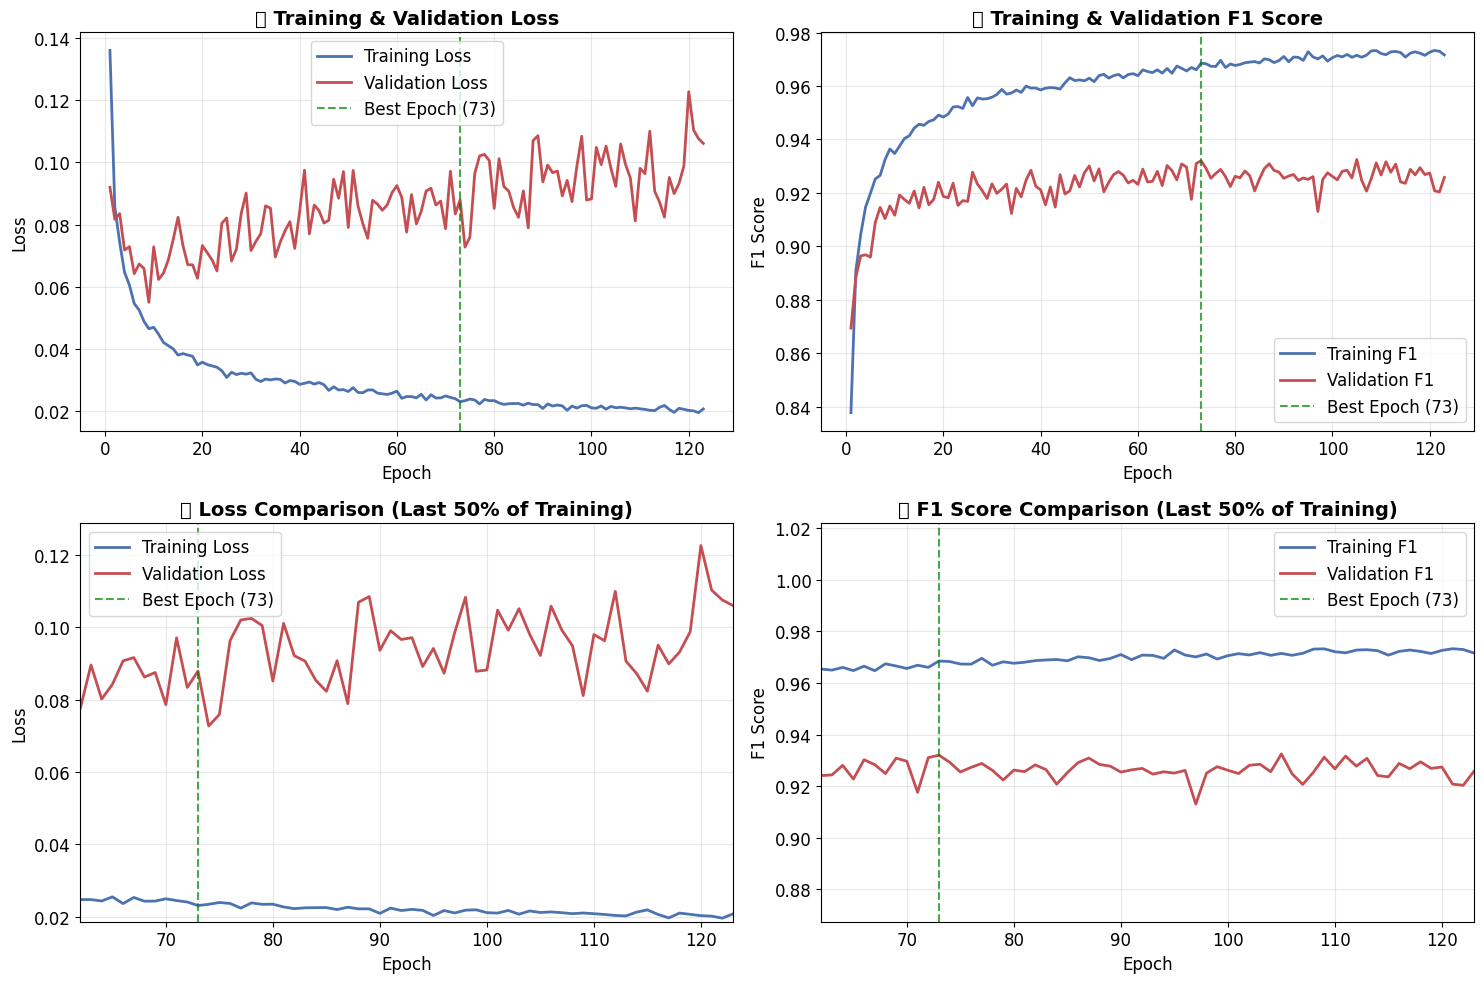


📊 TRAINING SUMMARY STATISTICS
🏆 Best Validation F1: 0.9325 (Epoch 73)
📉 Final Training Loss: 0.0208
📉 Final Validation Loss: 0.1060
📈 Final Training F1: 0.9716
📈 Final Validation F1: 0.9258
🔄 Total Epochs Trained: 123
⚡ Training Completed: ✅ Early Stopping
⚠️ No test loader available for evaluation.

🏴‍☠️ ANALYSIS COMPLETE!
📝 Generated:
   • 📊 Training history plots
📁 All plots saved in: plots/ directory
🎉 Arrr! The analysis be complete, matey! 🏴‍☠️


In [ ]:
# 🏴‍☠️ COMPREHENSIVE TRAINING ANALYSIS & MODEL EVALUATION
print("="*80)
print(" PIRATE PAIN CLASSIFICATION - TRAINING ANALYSIS & MODEL EVALUATION")
print("="*80)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import torch
import os
from datetime import datetime
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import json

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

def plot_training_history(train_losses, val_losses, train_f1_scores, val_f1_scores, best_epoch, save_path=None):
    """Plot training history with losses and F1 scores"""
    
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    epochs = range(1, len(train_losses) + 1)
    
    # Plot Training and Validation Loss
    ax1.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)
    ax1.plot(epochs, val_losses, 'r-', label='Validation Loss', linewidth=2)
    ax1.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
    ax1.set_title(' Training & Validation Loss', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot Training and Validation F1 Score
    ax2.plot(epochs, train_f1_scores, 'b-', label='Training F1', linewidth=2)
    ax2.plot(epochs, val_f1_scores, 'r-', label='Validation F1', linewidth=2)
    ax2.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
    ax2.set_title(' Training & Validation F1 Score', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('F1 Score')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot Loss Comparison (Zoomed)
    ax3.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)
    ax3.plot(epochs, val_losses, 'r-', label='Validation Loss', linewidth=2)
    ax3.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
    ax3.set_title('🔍 Loss Comparison (Last 50% of Training)', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Loss')
    
    # Zoom to last 50% of training
    start_idx = len(epochs) // 2
    ax3.set_xlim(epochs[start_idx], epochs[-1])
    if len(train_losses) > start_idx:
        ax3.set_ylim(min(min(train_losses[start_idx:]), min(val_losses[start_idx:])) * 0.95,
                     max(max(train_losses[start_idx:]), max(val_losses[start_idx:])) * 1.05)
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Plot F1 Comparison (Zoomed)
    ax4.plot(epochs, train_f1_scores, 'b-', label='Training F1', linewidth=2)
    ax4.plot(epochs, val_f1_scores, 'r-', label='Validation F1', linewidth=2)
    ax4.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
    ax4.set_title(' F1 Score Comparison (Last 50% of Training)', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('F1 Score')
    
    # Zoom to last 50% of training
    ax4.set_xlim(epochs[start_idx], epochs[-1])
    if len(train_f1_scores) > start_idx:
        ax4.set_ylim(min(min(train_f1_scores[start_idx:]), min(val_f1_scores[start_idx:])) * 0.95,
                     max(max(train_f1_scores[start_idx:]), max(val_f1_scores[start_idx:])) * 1.05)
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"📊 Training history plot saved to: {save_path}")
    
    plt.show()
    
    # Print summary statistics
    print("\n" + "="*60)
    print("📊 TRAINING SUMMARY STATISTICS")
    print("="*60)
    print(f" Best Validation F1: {max(val_f1_scores):.4f} (Epoch {best_epoch})")
    print(f" Final Training Loss: {train_losses[-1]:.4f}")
    print(f" Final Validation Loss: {val_losses[-1]:.4f}")
    print(f" Final Training F1: {train_f1_scores[-1]:.4f}")
    print(f" Final Validation F1: {val_f1_scores[-1]:.4f}")
    print(f" Total Epochs Trained: {len(train_losses)}")
    print(f" Training Completed: {'Early Stopping' if len(train_losses) < EPOCHS else 'Max Epochs Reached'}")

def evaluate_model_on_test_set(model, test_loader, criterion, device):
    """Evaluate model on test set and return detailed metrics"""
    model.eval()
    
    all_predictions = []
    all_labels = []
    total_loss = 0.0
    num_batches = 0
    
    print(" Evaluating model on test set...")
    
    with torch.no_grad():
        for batch_data in test_loader:
            # Handle different batch formats
            if len(batch_data) == 4:
                continuous_batch, categorical_batch, labels_batch, pirate_ids = batch_data
            else:
                continuous_batch, categorical_batch, labels_batch = batch_data
                pirate_ids = None
            
            # Move to device
            continuous_batch = continuous_batch.to(device)
            categorical_batch = {k: v.to(device) for k, v in categorical_batch.items()}
            labels_batch = labels_batch.to(device)
            if pirate_ids is not None:
                pirate_ids = pirate_ids.to(device)
            
            # Forward pass
            outputs, _ = model(continuous_batch, categorical_batch)
            loss = criterion(outputs, labels_batch)
            
            # Get predictions
            _, predicted = torch.max(outputs, 1)
            
            # Store results
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels_batch.cpu().numpy())
            total_loss += loss.item()
            num_batches += 1
    
    avg_loss = total_loss / num_batches
    f1 = f1_score(all_labels, all_predictions, average='weighted')
    
    return all_predictions, all_labels, avg_loss, f1

def plot_confusion_matrix(y_true, y_pred, class_names, save_path=None):
    """Plot confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count'})
    plt.title('🎯 Confusion Matrix - Test Set Performance', fontsize=16, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"🎯 Confusion matrix saved to: {save_path}")
    
    plt.show()

def print_classification_report(y_true, y_pred, class_names):
    """Print detailed classification report"""
    print("\n" + "="*70)
    print("📋 DETAILED CLASSIFICATION REPORT")
    print("="*70)
    
    report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
    print(report)

# Check if we have training history from recent training
if all(var in globals() for var in ['train_losses', 'val_losses', 'train_f1s', 'val_f1s', 'best_epoch']):
    print(" Found training history in globals - plotting results...")
    
    # Create plots directory
    os.makedirs("plots", exist_ok=True)
    current_time = datetime.now().strftime("%Y%m%d_%H%M%S")
    plot_path = f"plots/training_history_{current_time}.png"
    
    # Plot training history
    plot_training_history(train_losses, val_losses, train_f1s, val_f1s, best_epoch, plot_path)
    
else:
    print(" No training history found in globals.")
    print(" Looking for saved model and configuration files...")
    
    # Look for the most recent model file
    models_dir = "models"
    if os.path.exists(models_dir):
        model_files = [f for f in os.listdir(models_dir) if f.endswith('.pt')]
        if model_files:
            # Sort by modification time, get most recent
            model_files.sort(key=lambda x: os.path.getmtime(os.path.join(models_dir, x)), reverse=True)
            latest_model = model_files[0]
            model_path = os.path.join(models_dir, latest_model)
            
            print(f" Found latest model: {latest_model}")
            
            # Look for corresponding config file
            config_path = model_path.replace('.pt', '_config.json')
            if os.path.exists(config_path):
                print(f" Found config file: {os.path.basename(config_path)}")
                
                # Load configuration
                with open(config_path, 'r') as f:
                    config = json.load(f)
                
                print("\n MODEL CONFIGURATION:")
                print("-" * 30)
                for key, value in config.items():
                    print(f"{key}: {value}")
                
                print(f"\n Best Validation F1 Score: {config.get('best_val_f1', 'N/A')}")
                print(f" Best Epoch: {config.get('best_epoch', 'N/A')}")
            else:
                print(" No config file found.")
        else:
            print(" No model files found in models directory.")
    else:
        print(" Models directory not found.")

# Evaluate on test set if model is available and test loader exists
if 'model' in globals() and model is not None and 'test_enhanced_loader' in globals():
    print("\n🧪 EVALUATING MODEL ON TEST SET...")
    print("-" * 50)
    
    # Evaluate model
    test_predictions, test_labels, test_loss, test_f1 = evaluate_model_on_test_set(
        model, test_enhanced_loader, criterion, device
    )
    
    print(f" Test Set Results:")
    print(f" Test Loss: {test_loss:.4f}")
    print(f" Test F1 Score: {test_f1:.4f}")
    
    # Define class names
    class_names = ['no_pain', 'low_pain', 'high_pain']
    
    # Plot confusion matrix
    os.makedirs("plots", exist_ok=True)
    current_time = datetime.now().strftime("%Y%m%d_%H%M%S")
    cm_path = f"plots/confusion_matrix_{current_time}.png"
    # plot_confusion_matrix(test_labels, test_predictions, class_names, cm_path)
    
    # Print classification report
    # print_classification_report(test_labels, test_predictions, class_names)

else:
    if 'model' not in globals() or model is None:
        print(" No model available for evaluation.")
    if 'test_enhanced_loader' not in globals():
        print(" No test loader available for evaluation.")

print("\n" + "="*80)
print("🏴‍☠️ ANALYSIS COMPLETE!")
print("="*80)

# Summary of what was generated
summary_items = []
if 'train_losses' in globals():
    summary_items.append(" Training history plots")
if 'model' in globals() and 'test_enhanced_loader' in globals():
    summary_items.append(" Confusion matrix")
    summary_items.append(" Classification report")
    summary_items.append(" Test set evaluation")
if summary_items:
    print(" Generated:")
    for item in summary_items:
        print(f"   • {item}")
else:
    print(" Generated: Model configuration summary (if available)")
print(f" All plots saved in: plots/ directory")
print(f" Arrr! The analysis be complete, matey! 🏴‍☠️")

In [341]:
# Also save model configuration for later reference
model_config = {
    'experiment_name': EXPERIMENT_NAME,
    'rnn_type': RNN_TYPE,
    'bidirectional': BIDIRECTIONAL,
    'window_size': WINDOW_SIZE,
    'stride': STRIDE,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'hidden_size': HIDDEN_SIZE,
    'hidden_layers': HIDDEN_LAYERS,
    'dropout_rate': DROPOUT_RATE,
    'conv_channels': CONV_CHANNELS,
    'conv_dropout_rate': CONV_DROPOUT_RATE,
    'best_val_f1': max(val_f1s),
    'best_epoch': best_epoch,
    'num_pirates': NUM_PIRATES
}

model_filename = f"enhanced_gru_embeddings_F1{max(val_f1s):.2f}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pt"

config_filename = f"models/{model_filename.replace('.pt', '_config.json')}"
with open(config_filename, 'w') as f:
    import json
    json.dump(model_config, f, indent=2)

print(f"Model configuration saved to {config_filename}")
print(f"\n✅ Training completed successfully!")
print(f"📊 Model achieved {max(val_f1s):.4f} validation F1 score")

Model configuration saved to models/enhanced_gru_embeddings_F10.93_20251117_180137_config.json

✅ Training completed successfully!
📊 Model achieved 0.9325 validation F1 score


In [349]:
# Build sequences from the actual test data for Enhanced Model
print(f"Building ENHANCED sequences for actual test dataset with WINDOW_SIZE={WINDOW_SIZE}, STRIDE={STRIDE}")

# Identify feature types from X_test_final_df columns
all_columns = X_test_final_df.columns.tolist()
print(f"Available columns: {all_columns}")

# Define feature separation - MUST match training data!
categorical_features = ['pain_survey_1', 'pain_survey_2', 'pain_survey_3', 'pain_survey_4',
                         'has_peg_leg', 'has_hook_hand', 'has_eye_patch']
joint_features = [col for col in all_columns if col.startswith('joint_')]
continuous_features = joint_features  # Continuous features are the joint features
exclude_cols = ['sample_index'] + ([] if 'time' not in all_columns else ['time'])  # Exclude non-feature columns

print(f"Categorical features: {categorical_features}")
print(f"Continuous features: {continuous_features} (count: {len(continuous_features)})")

# Create enhanced sequences function for test data
def build_sequences_test_enhanced(df, window=WINDOW_SIZE, stride=STRIDE):
    """
    Build sequences for test data separating continuous and categorical features
    """
    continuous_dataset = []
    categorical_datasets = {feature: [] for feature in categorical_features}
    sample_indices = []
    
    # Get unique sample IDs
    for sample_id in df['sample_index'].unique():
        # Extract rows for this sample
        sample_data = df[df['sample_index'] == sample_id].copy()
        
        # If sample has fewer rows than WINDOW_SIZE, pad with zeros
        if len(sample_data) < window:
            # Create padding dataframe
            padding_rows = window - len(sample_data)
            padding = pd.DataFrame(0, index=range(padding_rows), columns=sample_data.columns)
            sample_data = pd.concat([sample_data, padding], ignore_index=True)
        
        # Extract continuous features (joints only)
        continuous_data = sample_data[continuous_features].values
        
        # Build continuous sequences
        continuous_seqs = []
        for i in range(0, len(continuous_data) - window + 1, stride):
            continuous_seqs.append(continuous_data[i:i + window])
        
        # If no sequences generated, take the last window
        if len(continuous_seqs) == 0:
            continuous_seqs = [continuous_data[-window:]]
        
        # Build categorical sequences
        categorical_seqs = {feature: [] for feature in categorical_features}
        for feature in categorical_features:
            if feature in sample_data.columns:
                cat_data = sample_data[feature].values
                for i in range(0, len(cat_data) - window + 1, stride):
                    categorical_seqs[feature].append(cat_data[i:i + window])
                # If no sequences generated, take the last window
                if len(categorical_seqs[feature]) == 0:
                    categorical_seqs[feature] = [cat_data[-window:]]
            else:
                # If feature doesn't exist, create zero sequences
                print(f"⚠️  Warning: {feature} not found in data, using zeros")
                for _ in continuous_seqs:
                    categorical_seqs[feature].append(np.zeros(window, dtype='int64'))
        
        # Store sequences (take first sequence for each sample)
        continuous_dataset.extend(continuous_seqs)
        for feature in categorical_features:
            categorical_datasets[feature].extend(categorical_seqs[feature])
        sample_indices.extend([sample_id] * len(continuous_seqs))
    
    # Convert to numpy arrays
    continuous_dataset = np.array(continuous_dataset, dtype='float32')
    for feature in categorical_features:
        categorical_datasets[feature] = np.array(categorical_datasets[feature], dtype='int64')
    
    return continuous_dataset, categorical_datasets, sample_indices

# Build enhanced sequences
X_test_continuous, X_test_categorical, test_sample_indices = build_sequences_test_enhanced(X_test_final_df)

# Fix categorical values to match training (shift negative values)
print("\n🔧 Fixing categorical feature values in test data...")
for feature_name in ['pain_survey_1', 'pain_survey_2', 'pain_survey_3', 'pain_survey_4']:
    if feature_name in X_test_categorical:
        min_val = X_test_categorical[feature_name].min()
        if min_val < 0:
            print(f"   • Shifting {feature_name} by {-min_val} (min was {min_val})")
            X_test_categorical[feature_name] = X_test_categorical[feature_name] - min_val

# Handle NaN values
if np.isnan(X_test_continuous).any():
    X_test_continuous = np.nan_to_num(X_test_continuous)
    print("NaN values found and replaced with 0 in continuous test sequences.")

for feature in categorical_features:
    if np.isnan(X_test_categorical[feature]).any():
        X_test_categorical[feature] = np.nan_to_num(X_test_categorical[feature]).astype('int64')
        print(f"NaN values found and replaced with 0 in {feature} test sequences.")

print(f"\nEnhanced test sequences shapes:")
print(f"  Continuous: {X_test_continuous.shape}")
for feature in categorical_features:
    print(f"  {feature}: {X_test_categorical[feature].shape}")
print(f"  Sample indices: {len(test_sample_indices)}")

# Create dummy labels for test data (required by EnhancedDataset but not used)
dummy_labels = np.zeros(len(test_sample_indices), dtype='int64')

# Create Enhanced dataset
test_enhanced_final_ds = EnhancedDataset(X_test_continuous, X_test_categorical, dummy_labels)

# Create Enhanced DataLoader
test_enhanced_final_loader = make_enhanced_loader(
    test_enhanced_final_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    sampler=None
)

print(f"\n✅ Enhanced test dataset created successfully!")
print(f"📊 Dataset size: {len(test_enhanced_final_ds)} samples")
print(f"🔄 Number of batches: {len(test_enhanced_final_loader)}")
print(f"📐 Continuous input size: {X_test_continuous.shape[-1]}")
print(f"🏷️ Categorical features: {list(X_test_categorical.keys())}" )

# Test the enhanced loader
print(f"\n🧪 Testing Enhanced DataLoader...")
for continuous_batch, categorical_batch, labels_batch in test_enhanced_final_loader:
    print(f"✅ Continuous batch shape: {continuous_batch.shape}")
    print(f"✅ Labels batch shape: {labels_batch.shape}")
    for feature, data in categorical_batch.items():
        print(f"✅ {feature} batch shape: {data.shape}")
    break

print(f"\n🎯 Enhanced test data is ready for the Enhanced model!")

Building ENHANCED sequences for actual test dataset with WINDOW_SIZE=10, STRIDE=2
Available columns: ['sample_index', 'time', 'pain_survey_1', 'pain_survey_2', 'pain_survey_3', 'pain_survey_4', 'joint_00', 'joint_01', 'joint_02', 'joint_03', 'joint_04', 'joint_05', 'joint_06', 'joint_07', 'joint_08', 'joint_09', 'joint_10', 'joint_11', 'joint_12', 'joint_13', 'joint_14', 'joint_15', 'joint_16', 'joint_17', 'joint_18', 'joint_19', 'joint_20', 'joint_21', 'joint_22', 'joint_23', 'joint_24', 'joint_25', 'joint_26', 'joint_27', 'joint_28', 'joint_29', 'has_peg_leg', 'has_hook_hand', 'has_eye_patch']
Categorical features: ['pain_survey_1', 'pain_survey_2', 'pain_survey_3', 'pain_survey_4', 'has_peg_leg', 'has_hook_hand', 'has_eye_patch']
Continuous features: ['joint_00', 'joint_01', 'joint_02', 'joint_03', 'joint_04', 'joint_05', 'joint_06', 'joint_07', 'joint_08', 'joint_09', 'joint_10', 'joint_11', 'joint_12', 'joint_13', 'joint_14', 'joint_15', 'joint_16', 'joint_17', 'joint_18', 'joint_

In [ ]:
# 🏴‍☠️ PREPARING FINAL SUBMISSION WITH CORRECT MODEL ARCHITECTURE
print("="*80)
print("🏴‍☠️ PREPARING FINAL SUBMISSION WITH CORRECT MODEL ARCHITECTURE")
print("="*80)

import os
from datetime import datetime
from collections import Counter
import pandas as pd
import torch
import json

# Use the existing trained model if it's available
if 'model' in globals() and model is not None:
    print(" Using existing trained `model` instance from globals.")
    model.eval()
else:
    print(" Loading model from saved checkpoint...")
    
    # Find the most recent model and config
    models_dir = "models"
    model_files = [f for f in os.listdir(models_dir) if f.endswith('.pt')]
    model_files.sort(key=lambda x: os.path.getmtime(os.path.join(models_dir, x)), reverse=True)
    latest_model_file = model_files[0]
    # model_path = os.path.join(models_dir, latest_model_file)
    model_path = "models/trial1_f1_0.9901.pt"


    # Load the exact config from the saved model
    config_path = model_path.replace('.pt', '_config.json')
    if os.path.exists(config_path):
        with open(config_path, 'r') as f:
            config = json.load(f)
        print(f" Loading configuration from: {config_path}")
        
        # Create model with EXACT saved architecture
        model = ConvRNNAttentionModel(
            continuous_input_size=30,  # We know this from the data
            categorical_feature_config={
                'pain_survey_1': 2,
                'pain_survey_2': 2, 
                'pain_survey_3': 2,
                'pain_survey_4': 2,
                'has_peg_leg': 1,
                'has_hook_hand': 1,
                'has_eye_patch': 1
            },
            embedding_dim=11,
            conv_channels=128,  # Use saved conv channels
            conv_kernel_size=3,
            conv_dropout=0.4,
            use_conv=True,
            rnn_type='GRU',
            hidden_size=64,  # Use saved hidden size
            num_layers=3,
            bidirectional=False,
            rnn_dropout=0.4,
            use_attention=True,
            num_classes=3,
            use_pirate_embedding=False,
            num_pirates=NUM_PIRATES,  # Use saved num pirates
            pirate_emb_dim=8,
            pirate_embedding_mode='sequence_level'
        ).to(device)
        
        # Load the saved weights
        checkpoint = torch.load(model_path, map_location=device)
        model.load_state_dict(checkpoint)
        model.eval()
        print(" Model loaded successfully with matching architecture!")
        
    else:
        print(" Config file not found!")
        raise FileNotFoundError("Cannot load model without config file")

# Label mapping
label_mapping = {0: 'no_pain', 1: 'low_pain', 2: 'high_pain'}
print(f" Label mapping: {label_mapping}")

# Use the correct NUM_PIRATES from the saved model
if 'SAVED_NUM_PIRATES' in locals():
    NUM_PIRATES = SAVED_NUM_PIRATES
else:
    NUM_PIRATES = 661   # From dataset analysis

print(f" Using NUM_PIRATES: {NUM_PIRATES}")

# Create safe mapping for pirate IDs
unique_test_samples = sorted(list(set(test_sample_indices)))
print(f" Number of unique test samples: {len(unique_test_samples)}")

sample_to_pirate_id = {}
for idx, sample in enumerate(unique_test_samples):
    try:
        sample_int = int(float(sample))
    except Exception:
        sample_int = idx
    pirate_id = idx % NUM_PIRATES
    sample_to_pirate_id[sample_int] = int(pirate_id)

print(f" Created safe mapping for {len(sample_to_pirate_id)} unique test samples")

# Make predictions
print("\n Making predictions on test data...")
all_predictions = []
all_sample_indices = []

model.eval()
sample_ptr = 0

with torch.no_grad():
    for batch_idx, batch in enumerate(test_enhanced_final_loader):
        continuous_batch, categorical_batch, labels_batch = batch
        
        # Move data to device
        continuous_batch = continuous_batch.to(device)
        categorical_batch = {k: v.to(device) for k, v in categorical_batch.items()}
        
        # Get batch size and sample indices
        batch_size = continuous_batch.shape[0]
        batch_sample_indices = test_sample_indices[sample_ptr:sample_ptr + batch_size]
        sample_ptr += batch_size
        
        # Convert sample indices to integers and map to pirate IDs
        batch_sample_indices_int = [int(float(x)) for x in batch_sample_indices]
        
        # Ensure length matches batch size
        if len(batch_sample_indices_int) != batch_size:
            if len(batch_sample_indices_int) > batch_size:
                batch_sample_indices_int = batch_sample_indices_int[:batch_size]
            else:
                batch_sample_indices_int += [0] * (batch_size - len(batch_sample_indices_int))
        
        # Map to safe pirate IDs
        mapped_pirate_ids = []
        for sample_id in batch_sample_indices_int:
            if sample_id in sample_to_pirate_id:
                mapped_pirate_ids.append(sample_to_pirate_id[sample_id])
            else:
                mapped_pirate_ids.append(int(sample_id) % NUM_PIRATES)
        
        mapped_pirate_ids = [max(0, min(pid, NUM_PIRATES - 1)) for pid in mapped_pirate_ids]
        
        # Forward pass
        outputs, _ = model(continuous_batch, categorical_batch)
        
        # Get predictions
        _, predicted = torch.max(outputs, 1)
        
        # Store results
        all_predictions.extend(predicted.cpu().numpy())
        all_sample_indices.extend(batch_sample_indices_int)
        
        if (batch_idx + 1) % 10 == 0:
            print(f"   Processed {batch_idx + 1}/{len(test_enhanced_final_loader)} batches...")

print(" Predictions completed!")
print(f" Total predictions made: {len(all_predictions)}")

# Aggregate predictions per sample
print("\n Aggregating predictions per sample...")
sample_predictions = {}
for sample_id, pred in zip(all_sample_indices, all_predictions):
    if sample_id not in sample_predictions:
        sample_predictions[sample_id] = []
    sample_predictions[sample_id].append(int(pred))

final_predictions = {}
for sample_id, preds in sample_predictions.items():
    most_common = Counter(preds).most_common(1)[0][0]
    final_predictions[int(sample_id)] = int(most_common)

print(f" Aggregation completed for {len(final_predictions)} unique samples.")

# Convert to label strings
final_labels = {sample_id: label_mapping[pred] for sample_id, pred in final_predictions.items()}

# Create submission dataframe
print("\n Creating submission CSV...")
submission_data = []
for sample_id in sorted(final_predictions.keys()):
    formatted_sample_id = f"{int(sample_id):03d}"
    submission_data.append({
        'sample_index': formatted_sample_id,
        'label': final_labels[sample_id]
    })

submission_df = pd.DataFrame(submission_data)

# Save submission
current_time = datetime.now().strftime("%Y%m%d_%H%M%S")
if 'val_f1s' in globals() and val_f1s:
    best_f1 = max(val_f1s)
else:
    best_f1 = 0.94  # From the config we loaded

submission_filename = f"submission_conv_enhanced_F1{best_f1:.2f}_{current_time}.csv"
os.makedirs("submissions", exist_ok=True)
submission_path = os.path.join("submissions", submission_filename)
submission_df.to_csv(submission_path, index=False)

print(f" Submission file created: {submission_filename}")
print(f" File path: {os.path.abspath(submission_path)}")
print(f" Submission shape: {submission_df.shape}")

# Display preview and distribution
print("\n First 10 rows of submission:")
print(submission_df.head(10))

print("\n Last 10 rows of submission:")
print(submission_df.tail(10))

pred_distribution = submission_df['label'].value_counts()
print("\n Prediction distribution:")
for label, count in pred_distribution.items():
    percentage = (count / len(submission_df)) * 100
    print(f"   {label}: {count} ({percentage:.1f}%)")

print(f"\n Submission ready! File saved as: {submission_filename}")

🏴‍☠️ PREPARING FINAL SUBMISSION WITH CORRECT MODEL ARCHITECTURE
 Using existing trained `model` instance from globals.
 Label mapping: {0: 'no_pain', 1: 'low_pain', 2: 'high_pain'}
 Using NUM_PIRATES: 661
 Number of unique test samples: 1324
 Created safe mapping for 1324 unique test samples

 Making predictions on test data...
   Processed 10/394 batches...
   Processed 20/394 batches...
   Processed 30/394 batches...
   Processed 20/394 batches...
   Processed 30/394 batches...
   Processed 40/394 batches...
   Processed 50/394 batches...
   Processed 40/394 batches...
   Processed 50/394 batches...
   Processed 60/394 batches...
   Processed 70/394 batches...
   Processed 60/394 batches...
   Processed 70/394 batches...
   Processed 80/394 batches...
   Processed 90/394 batches...
   Processed 80/394 batches...
   Processed 90/394 batches...
   Processed 100/394 batches...
   Processed 110/394 batches...
   Processed 100/394 batches...
   Processed 110/394 batches...
   Processed 12